<a href="https://colab.research.google.com/github/smozwald/foundation-flood/blob/main/notebooks/03_initial_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase One Summary & Phase Two Planning

This notebook covers:
1. **Phase One status** — what we built, what data we have
2. **AI4GOOD / alternative flood mapping** — comparing with our current SAR Otsu approach
3. **Current data analysis** — strengths and weaknesses of the pixel approach
4. **Flood event visualisations** — mapped flooded vs unflooded agricultural pixels per event
5. **Fields of the World** — assessing a field-level alternative to pixel sampling
6. **Phase Two planning** — inundation method comparison and decision point

In [32]:
# CELL 1 — Install dependencies
!pip install psycopg2-binary python-dotenv pandas matplotlib shapely geopandas contextily whitebox earthengine-api folium pillow reportlab -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 1.6 MB/s eta 0:00:00


In [2]:
# CELL 2 — Imports & Supabase connection
import os
import io
import json
import base64
import urllib.request
from datetime import datetime, timedelta

import psycopg2
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
from PIL import Image

from google.colab import userdata

CONN_STRING = userdata.get('SUPABASE_CONN_STRING')

def db():
    return psycopg2.connect(CONN_STRING)

# Quick smoke-test
with db() as conn:
    cur = conn.cursor()
    cur.execute('SELECT COUNT(*) FROM pixels_static')
    n = cur.fetchone()[0]
print(f'Connected OK — {n:,} pixels in pixels_static')

Connected OK — 49,450 pixels in pixels_static


In [3]:
# CELL 3 — GEE auth
import ee
try:
    ee.Initialize(project='foundation-flood')
    print('GEE already initialised')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='foundation-flood')
    print('GEE initialised')

GEE initialised


---
## 1. Phase One Status

In [4]:
# CELL 4 — Phase One row-count summary
queries = {
    'discharge_stations':   'SELECT COUNT(*) FROM discharge_stations',
    'discharge_ts':         'SELECT COUNT(*) FROM discharge_ts',
    'flood_events':         'SELECT COUNT(*) FROM flood_events',
    'study_zones':          'SELECT COUNT(*) FROM study_zones',
    'zone_flood_analysis (SUCCESS)': """
        SELECT COUNT(*) FROM zone_flood_analysis WHERE status = 'SUCCESS'""",
    'pixels_static':        'SELECT COUNT(*) FROM pixels_static',
    'ts_sentinel1':         'SELECT COUNT(*) FROM ts_sentinel1',
    'pixel_flooded':        'SELECT COUNT(*) FROM pixel_flooded',
}

rows = []
with db() as conn:
    cur = conn.cursor()
    for label, sql in queries.items():
        cur.execute(sql)
        rows.append({'Table': label, 'Rows': cur.fetchone()[0]})

status_df = pd.DataFrame(rows)
status_df['Status'] = status_df.apply(
    lambda r: '✓ complete' if r['Rows'] > 0 else '— empty', axis=1
)
print(status_df.to_string(index=False))

                        Table  Rows     Status
           discharge_stations    13 ✓ complete
                 discharge_ts 52234 ✓ complete
                 flood_events   318 ✓ complete
                  study_zones    26 ✓ complete
zone_flood_analysis (SUCCESS)    64 ✓ complete
                pixels_static 49450 ✓ complete
                 ts_sentinel1 99728 ✓ complete
                pixel_flooded 62330 ✓ complete


In [5]:
# CELL 5 — Zone 000099_initial breakdown
ZONE_PATTERN = '000099_initial'

def read_sql(sql, conn, params=None):
      with conn.cursor() as cur:
          cur.execute(sql, params or {})
          cols = [d[0] for d in cur.description]
          return pd.DataFrame(cur.fetchall(), columns=cols)

with db() as conn:
      zone_df = read_sql("""
          SELECT
              zfa.zone_id,
              zfa.flood_event_id,
              fe.flood_start,
              fe.flood_end,
              fe.max_category,
              zfa.status,
              zfa.flooded_agri_pct   AS percentage_flooded,
              zfa.wet_scene_date     AS scene_date
          FROM zone_flood_analysis zfa
          JOIN flood_events fe ON fe.event_id = zfa.flood_event_id
          WHERE zfa.zone_id ~ %(pat)s
          ORDER BY fe.flood_start
      """, conn, {'pat': ZONE_PATTERN})

      pix_df = read_sql("""
          SELECT
              ps.pixel_id,
              ST_Y(ps.geom::geometry) AS lat,
              ST_X(ps.geom::geometry) AS lon,
              ps.elevation,
              ps.slope,
              ps.dist_to_river_m
          FROM pixels_static ps
          WHERE ps.zone_id ~ %(pat)s
      """, conn, {'pat': ZONE_PATTERN})

      flooded_df = read_sql("""
          SELECT
              pf.pixel_id,
              pf.flood_event_id,
              pf.is_flooded      AS flooded,
              pf.vv_change_db,
              pf.wet_obs_date
          FROM pixel_flooded pf
          JOIN pixels_static ps ON ps.pixel_id = pf.pixel_id
          WHERE ps.zone_id ~ %(pat)s
      """, conn, {'pat': ZONE_PATTERN})

zone_df['flood_start'] = pd.to_datetime(zone_df['flood_start'])
zone_df['flood_end']   = pd.to_datetime(zone_df['flood_end'])

print(f'Events: {len(zone_df)}  |  Pixels: {len(pix_df):,}  |  Flood labels: {len(flooded_df):,}')
print()
print(zone_df[['zone_id','flood_start','max_category','status','percentage_flooded','scene_date']].to_string(index=False
))

Events: 11  |  Pixels: 6,233  |  Flood labels: 62,330

       zone_id flood_start  max_category  status  percentage_flooded scene_date
000099_initial  2016-07-20             1    FAIL                 NaN 2016-07-26
000099_initial  2019-07-08             1 SUCCESS               13.74 2019-07-11
000099_initial  2019-08-03             1 SUCCESS               11.77 2019-08-16
000099_initial  2019-08-20             1 SUCCESS                6.40 2019-08-28
000099_initial  2021-08-02             1 SUCCESS               14.69 2021-08-17
000099_initial  2022-07-21             1 SUCCESS               16.47 2022-07-31
000099_initial  2022-08-04             1 SUCCESS                7.09 2022-08-12
000099_initial  2023-07-12             1 SUCCESS               17.65 2023-08-07
000099_initial  2024-07-08             2 SUCCESS               13.12 2024-07-20
000099_initial  2025-07-25             1 SUCCESS               14.48 2025-07-27
000099_initial  2025-08-29             5 SUCCESS               36

---
## 2. AI4GOOD & Alternative Flood Mapping Approaches

### What we built (Phase One)
We use Sentinel-1 SAR backscatter with an **Otsu threshold** to detect open water per zone per event. The threshold is computed on a VV-polarisation composite clipped to the zone, and pixels below the threshold are labelled flooded. Valley pixels (low-lying non-agricultural areas) are excluded.

**Strengths:**
- SAR penetrates cloud cover — critical during active monsoon floods
- Otsu is unsupervised and adapts to each scene
- GEE allows processing at scale without local compute

**Weaknesses:**
- Otsu can mis-classify smooth bare soil or dense crops as water
- SAR speckling adds noise at the pixel level
- Requires a good flood-free reference scene (temporal change detection would improve this)
- Revisit time (~6 days) means some short flood events are missed

### Alternatives

| Approach | Pros | Cons |
|----------|------|------|
| **JRC Global Surface Water** (Landsat) | Long record (1984–), monthly | Optical only — cloud-blocked during floods |
| **Copernicus EMS** | Human-validated, per-event maps | Sparse coverage, few Pakistan events |
| **AI4GOOD FloodAI** | DL model, uses S1+S2 fusion | Requires GPU, not always accessible |
| **Google Flood Hub** | Real-time, global inundation maps | API access limited, no historical per-pixel labels |
| **MODIS NRT Flood Product** (LANCE) | Near-real-time, free | 500 m resolution — too coarse for field level |
| **UNOSAT** | Validated disaster maps | Only major declared disasters |
| **Our SAR Otsu** | Cloud-free, adaptive, scriptable | See weaknesses above |

### AI4GOOD FloodAI note
The [AI4GOOD Lab FloodAI](https://floodai.ca/) project trains neural networks on fused S1+S2 imagery. Their models are available as checkpoints but require significant GPU compute. For historical ground-truth comparison in our zone, we could:
1. Pull their inference outputs for 2022–2025 Pakistan events if available via their API
2. Use JRC GSW monthly maps as an optical cross-check for events in dry months
3. Use Copernicus EMS activation maps for the Aug 2022 and Aug 2025 Pakistan floods (both are major activations)

**Recommendation:** For Phase Two ground truth validation, use **Copernicus EMS** maps for the 2022 and 2025 events (these are freely downloadable shapefiles). For the remaining events, our SAR Otsu labels are likely the best available option at this spatial resolution.

---
## 3. Current Data Analysis — Strengths & Weaknesses

In [6]:
# ---------------------------------------------------------------------------
# CELL 6 — Per-event flood summary (works whether pixel_flooded is empty or not)
# ---------------------------------------------------------------------------

def event_flood_summary(zone_df, flooded_df):
    """
    If pixel_flooded is populated: compute per-event pixel flood rate.
    Otherwise fall back to zone-level flooded_agri_pct.
    """
    success = zone_df[zone_df['status'] == 'SUCCESS'].copy()

    if len(flooded_df) == 0:
        print('pixel_flooded is empty — using zone-level flooded_agri_pct')
        return success[['flood_start', 'max_category', 'percentage_flooded']].rename(
            columns={'percentage_flooded': 'pct_flooded'}
        )

    agg = (
        flooded_df.groupby('flood_event_id')['flooded']
        .agg(total='count', flooded_n='sum')
        .assign(pct_flooded=lambda d: 100 * d['flooded_n'] / d['total'])
        .reset_index()
    )
    merged = success.merge(agg, on='flood_event_id', how='left')
    return merged[['flood_start', 'max_category', 'total', 'flooded_n', 'pct_flooded']]


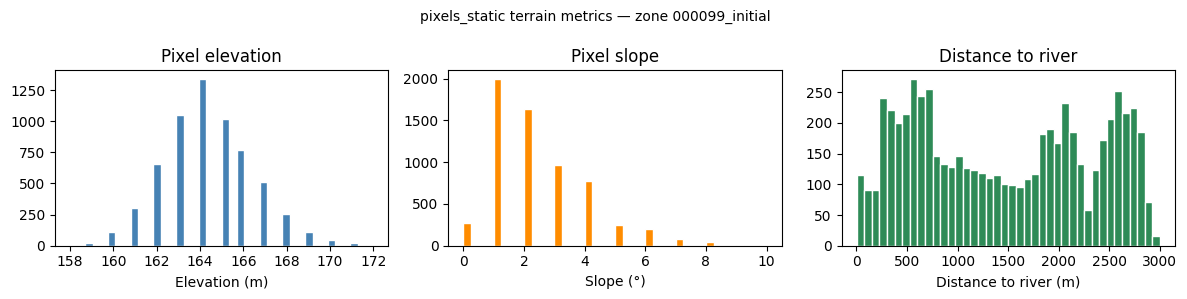

       elevation   slope  dist_to_river_m
count     6233.0  6233.0           6233.0
mean       164.4     2.4           1463.8
std          2.1     1.6            873.7
min        158.0     0.0              2.8
25%        163.0     1.0            640.2
50%        164.0     2.0           1449.7
75%        166.0     3.0           2231.5
max        172.0    10.0           3002.0


In [7]:
# CELL 7 — Pixel terrain distribution
if len(pix_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))

    axes[0].hist(pix_df['elevation'].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Elevation (m)')
    axes[0].set_title('Pixel elevation')

    axes[1].hist(pix_df['slope'].dropna(), bins=40, color='darkorange', edgecolor='white')
    axes[1].set_xlabel('Slope (°)')
    axes[1].set_title('Pixel slope')

    axes[2].hist(pix_df['dist_to_river_m'].dropna(), bins=40, color='seagreen', edgecolor='white')
    axes[2].set_xlabel('Distance to river (m)')
    axes[2].set_title('Distance to river')

    plt.suptitle('pixels_static terrain metrics — zone 000099_initial', fontsize=10)
    plt.tight_layout()
    plt.show()

    print(pix_df[['elevation','slope','dist_to_river_m']].describe().round(1))
else:
    print('No pixels found for zone pattern:', ZONE_PATTERN)

### Strengths of the current pixel approach

- **Scale**: ~49,000 pixels across 10 study zones gives a decent training set
- **Feature richness**: each pixel has elevation, slope, distance to river, and (once `ingest_s1_flood_pixels.py` runs) VV/VH time series
- **Agri-specific**: pixels are sampled from ESA WorldCover cropland class only
- **Multi-event labels**: up to 64 labelled events per zone enables temporal learning

### Weaknesses

- **Spatial resolution mismatch**: 10 m pixels don't respect field boundaries — a pixel may straddle a field edge or ditch
- **No field identity**: we can't compute per-field inundation statistics or duration without field boundaries
- **Scalability**: the GEE pixel sampling and S1 export pipeline is slow and manual per zone. Adding new rivers requires re-running all 5 steps with careful parameterisation
- **Label noise**: the Otsu-derived `flooded` label propagates any SAR mis-classification into the training signal
- **No duration signal**: we know if a pixel was flooded at the S1 acquisition date, not how long it stayed flooded

---
## 4. Flood Event Visualisations

In [8]:
# CELL 8 — Fetch S2 RGB thumbnail from GEE for a zone centred on pixel cloud
import os
os.makedirs('temp_images', exist_ok=True)

def fetch_s2_thumbnail(lat_center, lon_center, date_str, buffer_m=5000, width=512):
    """Return PIL Image of S2 RGB around (lat, lon) near date_str."""
    pt = ee.Geometry.Point([lon_center, lat_center])
    region = pt.buffer(buffer_m).bounds()
    date = ee.Date(date_str)
    s2 = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(region)
        .filterDate(date.advance(-60, 'day'), date.advance(60, 'day'))
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
        .sort('CLOUDY_PIXEL_PERCENTAGE')
        .first()
        .select(['B4', 'B3', 'B2'])
    )
    url = s2.getThumbURL({
        'region': region,
        'dimensions': width,
        'format': 'png',
        'min': 0,
        'max': 3000,
        'gamma': 1.4,
    })
    with urllib.request.urlopen(url) as resp:
        img = Image.open(io.BytesIO(resp.read()))
    return img, region.getInfo()

print('S2 thumbnail helper defined')

S2 thumbnail helper defined


S2 basemap loaded (72.4374,31.5222) → (72.5424,31.6122)


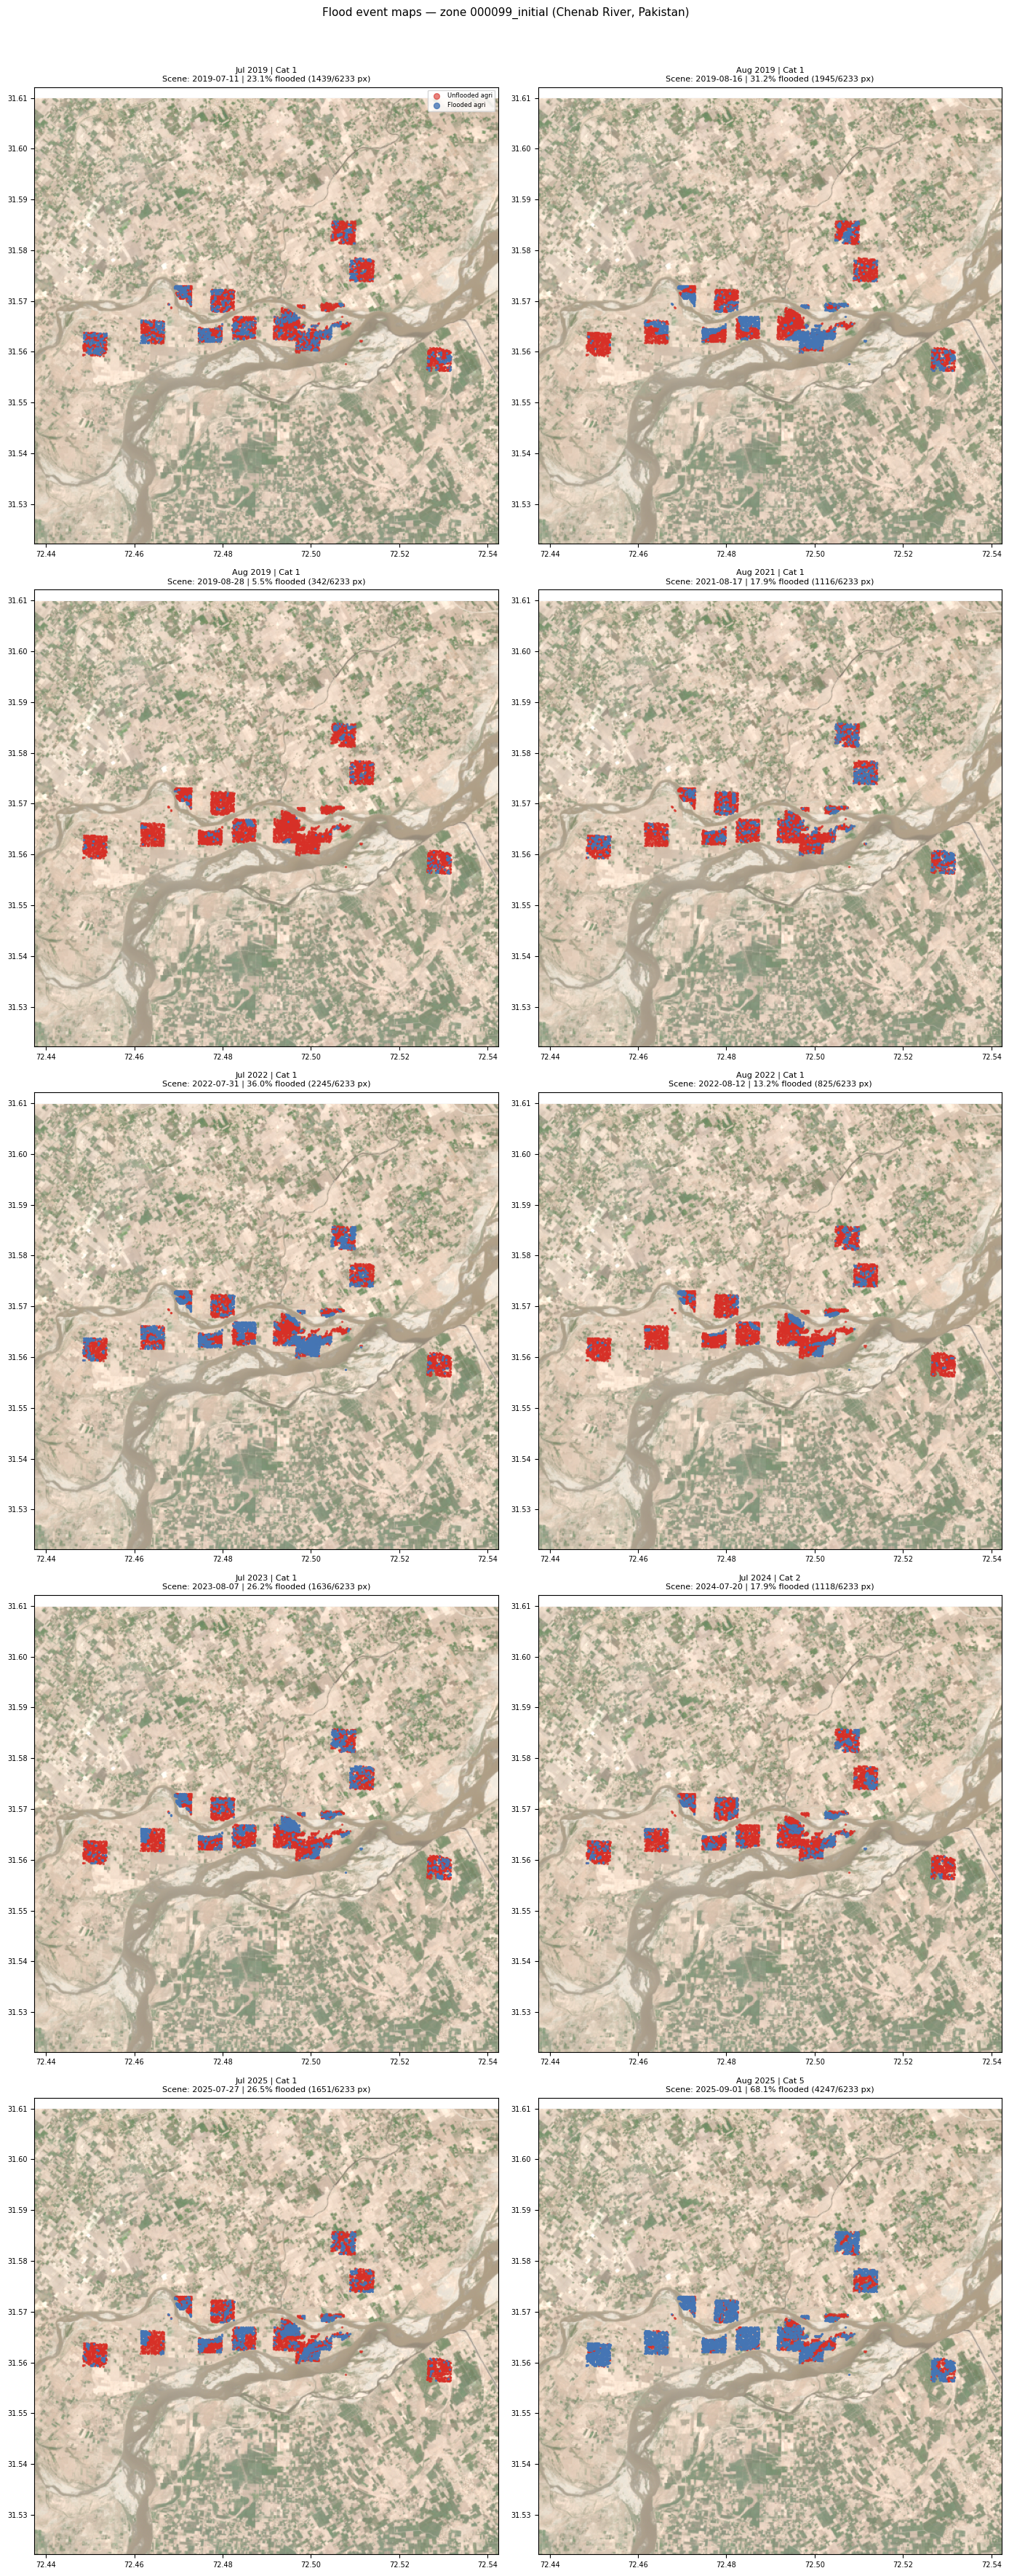

In [9]:
# ---------------------------------------------------------------------------
# CELL 9 — Flooded vs unflooded pixels per event on S2 basemap
# ---------------------------------------------------------------------------
# Paste from here into Colab Cell 9 (after Cell 5 has run).
# Requires: zone_df, pix_df, flooded_df, fetch_s2_thumbnail, ee, pd, plt

success_events = zone_df[zone_df['status'] == 'SUCCESS'].copy()
success_events['flood_start'] = pd.to_datetime(success_events['flood_start'])
success_events = success_events.reset_index(drop=True)

if len(pix_df) == 0:
    print('No pixel data — skipping visualisation')
else:
    lat_c = pix_df['lat'].mean()
    lon_c = pix_df['lon'].mean()

    ref_date = success_events.iloc[0]['flood_start'].strftime('%Y-%m-%d') if len(success_events) > 0 else '2023-01-01'
    try:
        bg_img, region_info = fetch_s2_thumbnail(lat_c, lon_c, ref_date)
        coords = region_info['coordinates'][0]
        lon_min = min(c[0] for c in coords)
        lon_max = max(c[0] for c in coords)
        lat_min = min(c[1] for c in coords)
        lat_max = max(c[1] for c in coords)
        has_bg = True
        print(f'S2 basemap loaded ({lon_min:.4f},{lat_min:.4f}) → ({lon_max:.4f},{lat_max:.4f})')
    except Exception as e:
        print(f'S2 basemap unavailable ({e}) — plotting without background')
        has_bg = False
        lon_min, lon_max = pix_df['lon'].min() - 0.01, pix_df['lon'].max() + 0.01
        lat_min, lat_max = pix_df['lat'].min() - 0.01, pix_df['lat'].max() + 0.01

    n_events = len(success_events)
    ncols = 2
    nrows = (n_events + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7 * nrows))
    if n_events == 1:
        axes = [[axes]]
    elif nrows == 1:
        axes = [axes]

    for idx, (_, ev) in enumerate(success_events.iterrows()):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]

        if has_bg:
            ax.imshow(bg_img, extent=[lon_min, lon_max, lat_min, lat_max], aspect='auto', alpha=0.6)

        ev_flooded = flooded_df[flooded_df['flood_event_id'] == ev.get('flood_event_id')] if len(flooded_df) > 0 else pd.DataFrame()

        if len(ev_flooded) > 0:
            merged = pix_df.merge(ev_flooded[['pixel_id', 'flooded']], on='pixel_id', how='left')
            merged['flooded'] = merged['flooded'].fillna(False)
            unflooded = merged[~merged['flooded']]
            flooded   = merged[merged['flooded']]
            ax.scatter(unflooded['lon'], unflooded['lat'], s=2, c='#d73027', alpha=0.6, label='Unflooded agri')
            ax.scatter(flooded['lon'],   flooded['lat'],   s=2, c='#4575b4', alpha=0.8,  label='Flooded agri')
            n_fl = int(merged['flooded'].sum())
            pct_str = f"{100 * n_fl / len(merged):.1f}% flooded ({n_fl}/{len(merged)} px)"
        else:
            ax.scatter(pix_df['lon'], pix_df['lat'], s=2, c='#999999', alpha=0.5, label='Agri pixels')
            pct_str = f"{ev['percentage_flooded']:.1f}% flooded (zone-level)"

        scene = str(ev['scene_date']) if pd.notnull(ev.get('scene_date')) else str(ev['flood_start'].date())
        ax.set_title(
            f"{ev['flood_start'].strftime('%b %Y')} | Cat {int(ev['max_category'])}\n"
            f"Scene: {scene} | {pct_str}",
            fontsize=8
        )
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.tick_params(labelsize=7)
        if idx == 0:
            ax.legend(loc='upper right', fontsize=6, markerscale=4)

    for idx in range(n_events, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    plt.suptitle('Flood event maps — zone 000099_initial (Chenab River, Pakistan)', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


2022: flood_start=2022-07-21  scene=2022-07-31  zone-level=16.5%
2025: flood_start=2025-08-29  scene=2025-09-01  zone-level=36.9%

2022: fixed-threshold SAR ...
  Fixed threshold: 1851 flooded / 6233 px (6233 have vv_change_db)
2022: reference layer ...
  JRC GSW failed: JRC GSW has no data for 2022/07 — dataset ends 2021. No optical reference available (monsoon cloud cover also makes optical unreliable for Pakistan flood events; SAR is the right tool here).

2025: fixed-threshold SAR ...
  Fixed threshold: 3463 flooded / 6233 px (6233 have vv_change_db)
2025: reference layer ...
  JRC GSW failed: JRC GSW has no data for 2025/08 — dataset ends 2021. No optical reference available (monsoon cloud cover also makes optical unreliable for Pakistan flood events; SAR is the right tool here).


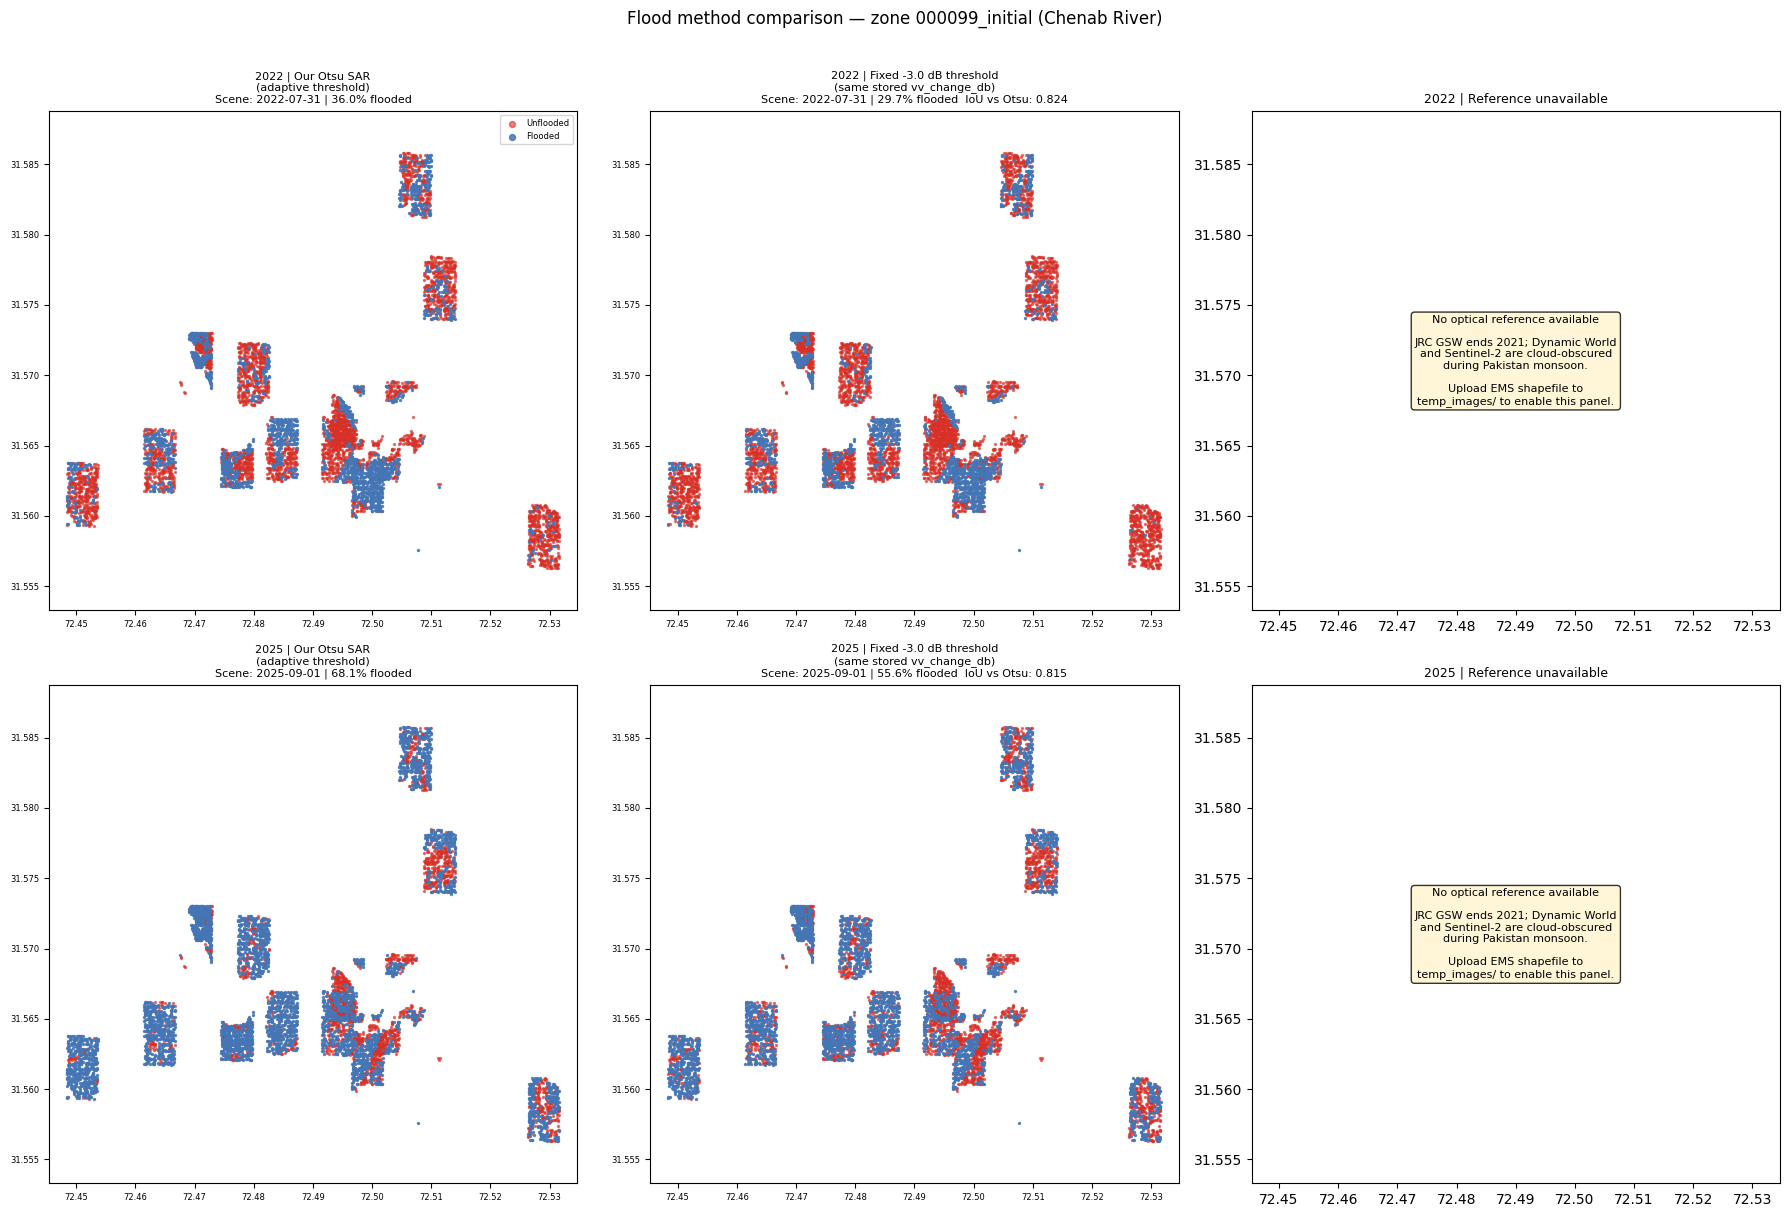

In [10]:
# CELL 10 — Method comparison: Otsu vs fixed-threshold SAR vs JRC GSW / EMS
# ---------------------------------------------------------------------------
# Panel 1: Our Otsu (stored is_flooded from pixel_flooded)
# Panel 2: Fixed -3 dB threshold applied to stored vv_change_db — no GEE re-fetch
# Panel 3: JRC GSW Monthly History from GEE (Landsat water mask for flood month).
#          Copernicus EMS portal does not expose stable download URLs, so JRC GSW
#          is used as the independent reference. If you manually upload an EMS
#          shapefile to temp_images/ it will be used instead.
# Paste from here into Colab Cell 10 (after Cell 5 has run).

import geopandas as gpd
from shapely.geometry import Point

SAR_CHANGE_THRESHOLD_DB = -3.0

# Optional manual override — upload EMS "Observed Event" shapefile to Colab:
#   2022 (EMSR629): https://emergency.copernicus.eu/mapping/list-of-components/EMSR629
#   2025 (EMSR838): https://emergency.copernicus.eu/mapping/list-of-components/EMSR838
EMS_PATHS = {
    '2022': 'temp_images/emsr629_observed_event.shp',
    '2025': 'temp_images/emsr838_observed_event.shp',
}

pad = 0.003
lon_min = pix_df['lon'].min() - pad;  lon_max = pix_df['lon'].max() + pad
lat_min = pix_df['lat'].min() - pad;  lat_max = pix_df['lat'].max() + pad


def _fixed_threshold_labels(pix_df, ev_flooded, threshold_db=SAR_CHANGE_THRESHOLD_DB):
    """Apply a fixed dB threshold to the stored vv_change_db values (no GEE needed)."""
    merged = pix_df[['pixel_id']].merge(
        ev_flooded[['pixel_id', 'vv_change_db']], on='pixel_id', how='left'
    )
    labels = (merged['vv_change_db'] < threshold_db).fillna(False).reset_index(drop=True)
    n_valid = ev_flooded['vv_change_db'].notna().sum()
    print(f"  Fixed threshold: {labels.sum()} flooded / {len(labels)} px "
          f"({n_valid} have vv_change_db)")
    return labels


def _ems_labels(pix_df, shp_path):
    """Point-in-polygon against EMS observed-event shapefile. Returns None if missing."""
    if not os.path.exists(shp_path):
        return None, None
    gdf = gpd.read_file(shp_path).to_crs('EPSG:4326')
    # Try standard EMS field filters; fall back to all polygons if nothing matches
    filtered = pd.DataFrame()
    for col in ['obj_type', 'symbology', 'TYPE']:
        if col in gdf.columns:
            filtered = gdf[gdf[col].str.lower().str.contains('flood|water|inundat', na=False)]
            if len(filtered):
                break
    if len(filtered) == 0:
        print(f"  EMS: no flood filter matched — using all {len(gdf)} polygons")
        filtered = gdf
    else:
        print(f"  EMS: {len(filtered)} flood polygons from {os.path.basename(shp_path)}")
    union = filtered.geometry.union_all()
    pts   = [Point(lon, lat) for lon, lat in zip(pix_df['lon'], pix_df['lat'])]
    labels = pd.Series([union.contains(p) for p in pts], index=pix_df.index)
    return labels, f'Copernicus EMS ({os.path.basename(shp_path)[:7].upper()})'


def _jrc_labels(pix_df, year, month, ee):
    """JRC GSW Monthly History — value 2 = water observed that month.
    Dataset covers 1984–2021; raises ValueError for later years."""
    col = (ee.ImageCollection('JRC/GSW1_4/MonthlyHistory')
           .filter(ee.Filter.calendarRange(year, year, 'year'))
           .filter(ee.Filter.calendarRange(month, month, 'month')))
    if col.size().getInfo() == 0:
        raise ValueError(
            f"JRC GSW has no data for {year}/{month:02d} — dataset ends 2021. "
            "No optical reference available (monsoon cloud cover also makes optical "
            "unreliable for Pakistan flood events; SAR is the right tool here)."
        )
    jrc = col.first()
    pts = ee.FeatureCollection([
        ee.Feature(ee.Geometry.Point([float(r['lon']), float(r['lat'])]),
                   {'pixel_id': r['pixel_id']})
        for _, r in pix_df.iterrows()
    ])
    sampled = jrc.sampleRegions(collection=pts, scale=30, geometries=False).getInfo()
    result  = {f['properties']['pixel_id']: f['properties'].get('water', 0) == 2
               for f in sampled['features']}
    labels  = pix_df['pixel_id'].map(result).fillna(False)
    print(f"  JRC GSW {year}/{month:02d}: {labels.sum()} water pixels / {len(labels)}")
    return labels


def _iou(a, b):
    a, b = a.astype(bool).values, b.astype(bool).values
    inter = (a & b).sum()
    union = (a | b).sum()
    return inter / union if union > 0 else float('nan')


# Find best SUCCESS event per year
events_to_compare = {}
for year in [2022, 2025]:
    matches = zone_df[
        (zone_df['flood_start'].dt.year == year) &
        (zone_df['status'] == 'SUCCESS')
    ].sort_values('percentage_flooded', ascending=False)
    if len(matches):
        events_to_compare[str(year)] = matches.iloc[0]
        print(f"{year}: flood_start={matches.iloc[0]['flood_start'].date()}  "
              f"scene={str(matches.iloc[0]['scene_date'])}  "
              f"zone-level={matches.iloc[0]['percentage_flooded']:.1f}%")
    else:
        print(f"{year}: no SUCCESS event found")


n_events = len(events_to_compare)
fig, axes = plt.subplots(n_events, 3, figsize=(18, 6 * n_events))
if n_events == 1:
    axes = [axes]

for row_i, (year_label, ev) in enumerate(events_to_compare.items()):
    ev_flooded = flooded_df[flooded_df['flood_event_id'] == ev['flood_event_id']]
    merged = pix_df.merge(ev_flooded[['pixel_id', 'flooded']], on='pixel_id', how='left')
    merged['flooded'] = merged['flooded'].fillna(False)
    our   = merged['flooded'].reset_index(drop=True)
    scene = str(ev['scene_date']) if pd.notnull(ev['scene_date']) else '—'

    print(f'\n{year_label}: fixed-threshold SAR ...')
    sar_fixed = _fixed_threshold_labels(pix_df, ev_flooded)

    print(f'{year_label}: reference layer ...')
    ref_labels, ref_title = _ems_labels(pix_df, EMS_PATHS.get(year_label, ''))
    if ref_labels is None:
        year_int  = int(ev['flood_start'].year)
        month_int = int(ev['flood_start'].month)
        try:
            ref_labels = _jrc_labels(pix_df, year_int, month_int, ee)
            ref_title  = f'JRC GSW {year_int}/{month_int:02d} (Landsat)'
        except Exception as e:
            print(f'  JRC GSW failed: {e}')
            ref_title  = 'Reference unavailable'

    panels = [
        ('Our Otsu SAR\n(adaptive threshold)', our, None),
        (f'Fixed {SAR_CHANGE_THRESHOLD_DB} dB threshold\n(same stored vv_change_db)', sar_fixed, our),
        (ref_title, ref_labels, our),
    ]

    for col_i, (title, labels, ref) in enumerate(panels):
        ax = axes[row_i][col_i]
        if labels is None:
            ax.text(0.5, 0.5,
                    'No optical reference available\n\n'
                    'JRC GSW ends 2021; Dynamic World\n'
                    'and Sentinel-2 are cloud-obscured\n'
                    'during Pakistan monsoon.\n\n'
                    'Upload EMS shapefile to\ntemp_images/ to enable this panel.',
                    ha='center', va='center', transform=ax.transAxes, fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='#fff3cd', alpha=0.8))
            ax.set_title(f'{year_label} | {title}', fontsize=9)
            ax.set_xlim(lon_min, lon_max)
            ax.set_ylim(lat_min, lat_max)
            continue

        pct     = 100 * labels.sum() / len(labels)
        iou_str = f'  IoU vs Otsu: {_iou(ref, labels):.3f}' if ref is not None else ''
        fl      = pix_df[labels.values]
        unfl    = pix_df[~labels.values]
        ax.scatter(unfl['lon'], unfl['lat'], s=2, c='#d73027', alpha=0.6,  label='Unflooded')
        ax.scatter(fl['lon'],   fl['lat'],   s=2, c='#4575b4', alpha=0.85, label='Flooded')
        ax.set_title(f'{year_label} | {title}\nScene: {scene} | {pct:.1f}% flooded{iou_str}', fontsize=8)
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.tick_params(labelsize=6)
        if col_i == 0 and row_i == 0:
            ax.legend(loc='upper right', fontsize=6, markerscale=3)

plt.suptitle('Flood method comparison — zone 000099_initial (Chenab River)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Fields of the World — Feasibility Assessment

### What is Fields of the World?

[Fields of the World (FoTW)](https://fieldsofthe.world/) is a global benchmark dataset of agricultural field boundaries derived from crowdsourced mapping and ML inference. The 2025 basemap provides polygon boundaries for fields worldwide, with a confidence score per field.

**Access options:**
- GEE asset: `projects/sat-io/open-datasets/FIELDS-OF-THE-WORLD` (check availability)
- Direct download: country-level GeoPackage files from the FoTW website
- Google Drive shared datasets

We will use fields with **confidence ≥ 70%** (2025 basemap), filtered to our zone 000099_initial bounding box.

### Pros vs Pixel approach

| Factor | Pixel (current) | Fields of the World |
|--------|----------------|--------------------|
| Spatial unit | 10 m raster pixel | Field polygon (variable size) |
| Boundary respect | No — straddles edges | Yes — flood % per whole field |
| Interpretability | Hard (49k isolated points) | High — field-level decision |
| Completeness | ESA WorldCover coverage | FoTW coverage (may have gaps) |
| Inundation duration | Single date per event | Can compute A–B days if multi-date |
| Scalability | Slow (GEE per-pixel export) | Faster (zonal stats per field) |
| Training signal | Clean grid, easy to batch | Irregular polygons, need zonal aggregation |
| Model type suitability | CNN / tabular | Graph / tabular / polygon-aware CNN |

**Verdict:** Field-level is more interpretable and actionable ("field X will flood") but adds complexity in zonal aggregation and requires FoTW to have good coverage in Pakistan. The pixel approach is simpler to train but produces outputs that are harder to use in practice.

Zone bbox: lon [72.4298, 72.5498]  lat [31.5072, 31.6272]
Querying FoTW predictions (30–90 s while DuckDB prunes ~1000 files by bbox) ...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Rows returned: 24949
Fields clipped to zone: 24947


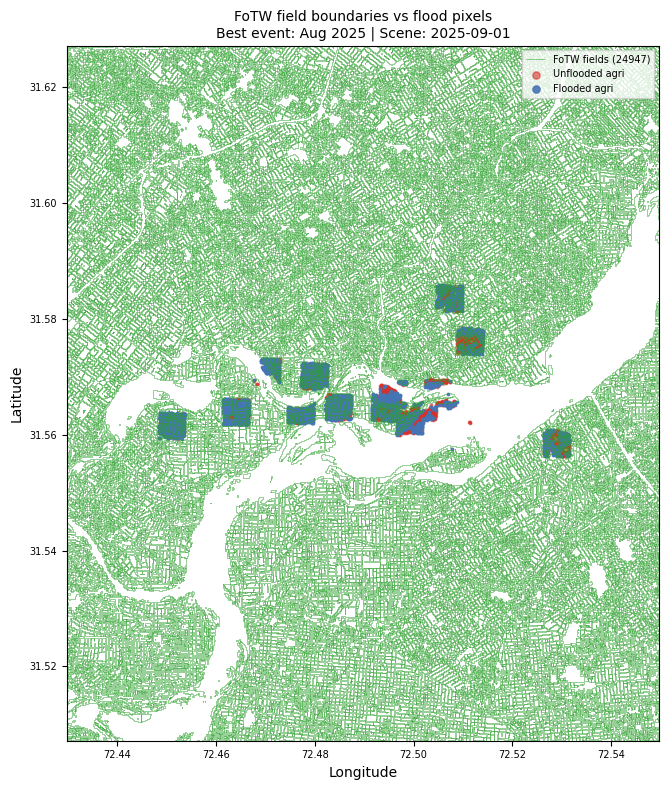

In [11]:
# ---------------------------------------------------------------------------
# CELL 11 — Load Fields of The World for zone 000099_initial  (WORKING)
# ---------------------------------------------------------------------------
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'duckdb', 'geopandas', 'shapely'])
import duckdb
import geopandas as gpd
from shapely.geometry import box

FTW_YEAR = 2024   # global layer has 2024 & 2025; pick one to avoid duplicate fields

if len(pix_df) == 0:
    print('No pixel data — skipping FoTW')
else:
    lat_c, lon_c = pix_df['lat'].mean(), pix_df['lon'].mean()
    buf = 0.06  # ~7 km buffer
    xmin, xmax = lon_c - buf, lon_c + buf
    ymin, ymax = lat_c - buf, lat_c + buf
    print(f'Zone bbox: lon [{xmin:.4f}, {xmax:.4f}]  lat [{ymin:.4f}, {ymax:.4f}]')

    # --- Source Cooperative anonymous S3 access (this is what was missing) ---
    con = duckdb.connect()
    for stmt in [
        "INSTALL spatial; LOAD spatial;",
        "INSTALL httpfs; LOAD httpfs;",
        "SET s3_endpoint='data.source.coop';",
        "SET s3_url_style='path';",
        "SET s3_region='us-east-1';",
        "SET s3_access_key_id='';",
        "SET s3_secret_access_key='';",
        "SET s3_use_ssl=true;",
    ]:
        con.execute(stmt)

    # Note: bucket-prefixed path is wrong with the custom endpoint — use s3://ftw/...
    FTW_S3 = 's3://ftw/global-data/predictions/vectors/alpha/results/*.parquet'

    fields_gdf = None
    try:
        print('Querying FoTW predictions (30–90 s while DuckDB prunes ~1000 files by bbox) ...')
        query = f"""
            SELECT
                time, label,
                ST_AsWKB(geometry) AS geometry
            FROM read_parquet('{FTW_S3}', hive_partitioning=1)
            WHERE label = 'field'
              AND struct_extract(bbox, 'xmax') >= {xmin}
              AND struct_extract(bbox, 'xmin') <= {xmax}
              AND struct_extract(bbox, 'ymax') >= {ymin}
              AND struct_extract(bbox, 'ymin') <= {ymax}
              AND time >= '{FTW_YEAR}-01-01'
              AND time <  '{FTW_YEAR + 1}-01-01'
        """
        result = con.execute(query).df()
        print(f'  Rows returned: {len(result)}')
        if len(result) > 0:
            fields_gdf = gpd.GeoDataFrame(
                result,
                geometry=gpd.GeoSeries.from_wkb(result['geometry'].apply(bytes)),
                crs='EPSG:4326'
            )
        else:
            print('  No fields in bbox for that year — try the other year, widen buf, '
                  'or check the zone centroid.')
    except Exception as e:
        print(f'FoTW query failed: {e}')
        print('Dataset page: https://source.coop/ftw/global-data')
    finally:
        con.close()

    if fields_gdf is not None and len(fields_gdf) > 0:
        fields_gdf = fields_gdf.clip(box(xmin, ymin, xmax, ymax))
        print(f'Fields clipped to zone: {len(fields_gdf)}')

        fig, ax = plt.subplots(figsize=(10, 8))
        fields_gdf.boundary.plot(ax=ax, linewidth=0.5, color='#2ca02c',
                                 alpha=0.7, label=f'FoTW fields ({len(fields_gdf)})')

        best_events = zone_df[zone_df['status'] == 'SUCCESS'].sort_values(
            'percentage_flooded', ascending=False)
        if len(best_events) > 0:
            best_ev = best_events.iloc[0]
            ev_flooded = flooded_df[flooded_df['flood_event_id'] == best_ev['flood_event_id']]
            merged = pix_df.merge(ev_flooded[['pixel_id', 'flooded']], on='pixel_id', how='left')
            merged['flooded'] = merged['flooded'].fillna(False)
            unfl, fl = merged[~merged['flooded']], merged[merged['flooded']]
            ax.scatter(unfl['lon'], unfl['lat'], s=3, c='#d73027', alpha=0.6, label='Unflooded agri')
            ax.scatter(fl['lon'],   fl['lat'],   s=3, c='#4575b4', alpha=0.9, label='Flooded agri')
            scene = str(best_ev['scene_date']) if pd.notnull(best_ev.get('scene_date')) else '—'
            ax.set_title(f"FoTW field boundaries vs flood pixels\n"
                         f"Best event: {best_ev['flood_start'].strftime('%b %Y')} | Scene: {scene}",
                         fontsize=10)
        else:
            ax.scatter(pix_df['lon'], pix_df['lat'], s=3, c='#999999', alpha=0.5, label='Agri pixels')
            ax.set_title('FoTW field boundaries — zone 000099_initial', fontsize=10)

        ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
        ax.tick_params(labelsize=7)
        ax.legend(loc='upper right', fontsize=7, markerscale=3)
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        plt.tight_layout(); plt.show()

In [12]:
# CELL 12 — Compute per-field flood % per event (if FoTW loaded)
# For each field polygon, intersect with zone_flood_analysis SAR flood mask and
# compute percentage of field pixels classified as flooded.
# Also compute inundation duration using the GEE S1 time series.

# Duration bins (days from flood start):
DURATION_BINS = [(0, 4), (4, 8), (8, 16), (16, 32)]
n_fields = len(fields_gdf) if fields_gdf is not None else 0
def compute_field_flood_pct(field_fc, zone_id, event_id, scene_date, conn_string):
    """
    Placeholder — in production this would:
    1. Load the SAR flood mask raster from GEE for this zone+event
    2. Reduce each field polygon to a mean flood value
    3. Return a GeoDataFrame with field_id, pct_flooded, inundation_days
    """
    raise NotImplementedError(
        'Implement after deciding: use GEE zonal stats (reduceRegions) '
        'on the SAR flood mask, or load pixel_flooded labels and spatially join.'
    )

print('Per-field flood % function stubbed — implement after FoTW access confirmed.')
print()
print('Inundation duration approach:')
print('  For each S1 acquisition within flood_start → flood_end + 12d:')
print('  If pixel/field is flooded at T1 but not T2 (next acquisition), count T1→T2 as flooded.')
print('  Sum across acquisitions to get total flooded days.')
print()
for a, b in DURATION_BINS:
    print(f'  Bin: {a}–{b} days flooded')

Per-field flood % function stubbed — implement after FoTW access confirmed.

Inundation duration approach:
  For each S1 acquisition within flood_start → flood_end + 12d:
  If pixel/field is flooded at T1 but not T2 (next acquisition), count T1→T2 as flooded.
  Sum across acquisitions to get total flooded days.

  Bin: 0–4 days flooded
  Bin: 4–8 days flooded
  Bin: 8–16 days flooded
  Bin: 16–32 days flooded


Field size (using cached area_ha):


,Statistic,Value (ha)
0,Total Fields,"24,947"
1,Mean Area,0.327
2,Median Area,0.195
3,Min Area,0.0024
4,Max Area,25.934
5,Std Dev,0.551
6,Top 10 Threshold,9.489


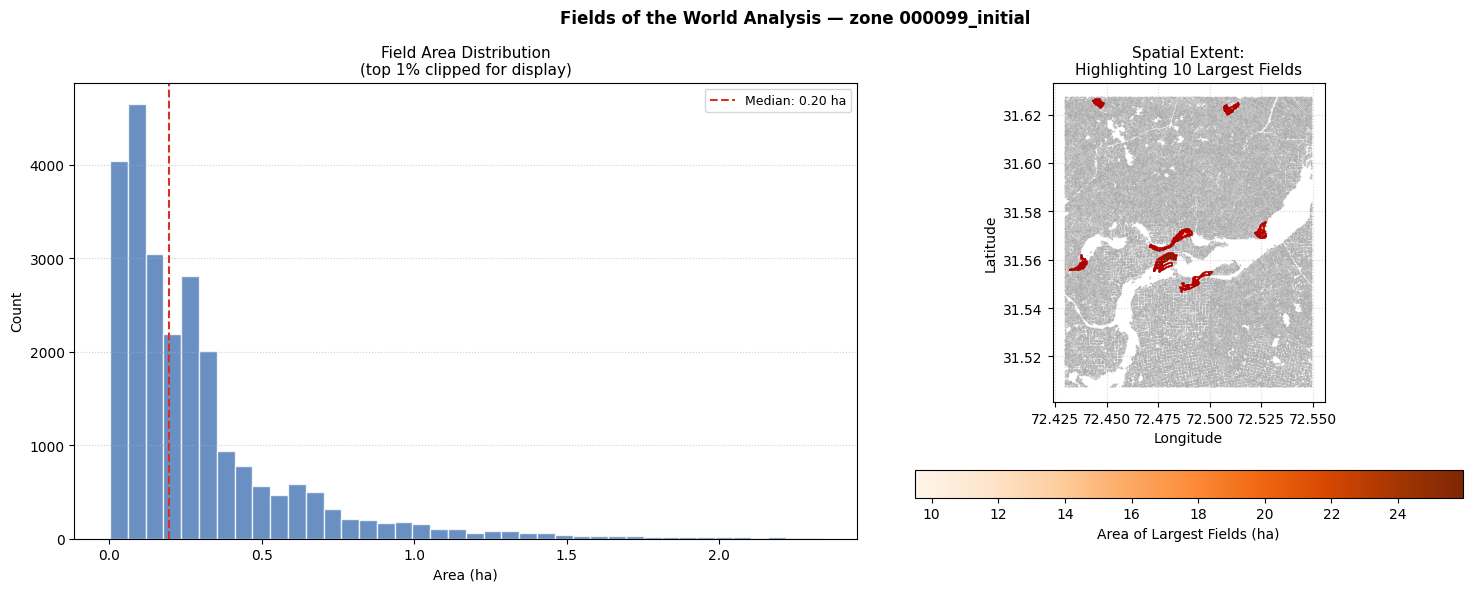

In [15]:
# ---------------------------------------------------------------------------
# CELL 13 — FoTW fields area distribution, statistics, and largest fields map
# ---------------------------------------------------------------------------
import pandas as pd

if len(pix_df) > 0 and 'fields_gdf' in dir() and fields_gdf is not None and len(fields_gdf) > 0:
    try:
        # Recompute centroid locally (cheap) rather than relying on Cell 11's
        # lon_c/lat_c still being in scope
        lon_c = pix_df['lon'].mean()
        lat_c = pix_df['lat'].mean()

        # --- Field size check: project to local UTM for true area in m² ---
        if 'area_ha' not in fields_gdf.columns:
            utm_zone = int((lon_c + 180) / 6) + 1
            epsg = 32600 + utm_zone if lat_c >= 0 else 32700 + utm_zone
            fields_utm = fields_gdf.to_crs(epsg=epsg)
            fields_gdf['area_ha'] = fields_utm.geometry.area / 10_000  # m² -> hectares
            print(f'Field size (UTM zone {utm_zone}, EPSG:{epsg}):')
        else:
            print('Field size (using cached area_ha):')

        areas = fields_gdf['area_ha']
        n_fields = len(fields_gdf)
        median_ha = areas.median()

        # Identify top 10 largest fields
        top10_fields = fields_gdf.nlargest(10, 'area_ha')

        # --- Generate Summary Statistics Table ---
        stats_df = pd.DataFrame({
            'Statistic': [
                'Total Fields',
                'Mean Area',
                'Median Area',
                'Min Area',
                'Max Area',
                'Std Dev',
                'Top 10 Threshold'
            ],
            'Value (ha)': [
                f'{n_fields:,}',
                f'{areas.mean():.3f}',
                f'{median_ha:.3f}',
                f'{areas.min():.4f}',
                f'{areas.max():.3f}',
                f'{areas.std():.3f}',
                f'{top10_fields["area_ha"].min():.3f}'
            ]
        })

        # Display the table in the notebook output
        from IPython.display import display
        display(stats_df)
        print('\n')

        # --- Plotting: Side-by-Side Histogram and Spatial Map ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Left plot: Area Distribution Histogram
        clip_at = areas.quantile(0.99)
        axes[0].hist(areas[areas <= clip_at], bins=40, color='#4575b4', alpha=0.8, edgecolor='white')
        axes[0].axvline(median_ha, color='#d73027', linestyle='--', linewidth=1.5,
                      label=f'Median: {median_ha:.2f} ha')
        axes[0].set_title('Field Area Distribution\n(top 1% clipped for display)', fontsize=11)
        axes[0].set_xlabel('Area (ha)')
        axes[0].set_ylabel('Count')
        axes[0].legend(fontsize=9)
        axes[0].grid(axis='y', linestyle=':', alpha=0.6)

        # Right plot: Spatial Map highlighting top 10 fields
        # Plot all fields as a light grey context background
        fields_gdf.plot(ax=axes[1], color='#e0e0e0', edgecolor='#aaaaaa', linewidth=0.3, label='Other Fields')

        # Overlay the top 10 largest fields with a distinct red/orange color
        top10_fields.plot(
            ax=axes[1],
            column='area_ha',
            cmap='Oranges',
            edgecolor='#b30000',
            linewidth=1.2,
            legend=True,
            legend_kwds={'label': 'Area of Largest Fields (ha)', 'orientation': 'horizontal', 'shrink': 0.7}
        )

        axes[1].set_title('Spatial Extent:\nHighlighting 10 Largest Fields', fontsize=11)
        axes[1].set_xlabel('Longitude')
        axes[1].set_ylabel('Latitude')
        axes[1].grid(linestyle=':', alpha=0.5)

        plt.suptitle('Fields of the World Analysis — zone 000099_initial', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'Could not render FoTW comparison: {e}')
else:
    print('FoTW not loaded — run Cell 11 first and confirm access')

          CELL 13.5: CLEANING & COVERAGE REPORT   
Initial FoTW Field Count:   24,549
99.9th Percentile Cutoff:   1.549 ha
Outlier Fields Removed:     123
Cleaned Fields Retained:    24,426
--------------------------------------------------
Fields Intersected by Pixels: 346 out of 24,426
Coverage Ratio:             1.42%



/tmp/ipykernel_397/3806682494.py:98: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', fontsize=8, markerscale=2)


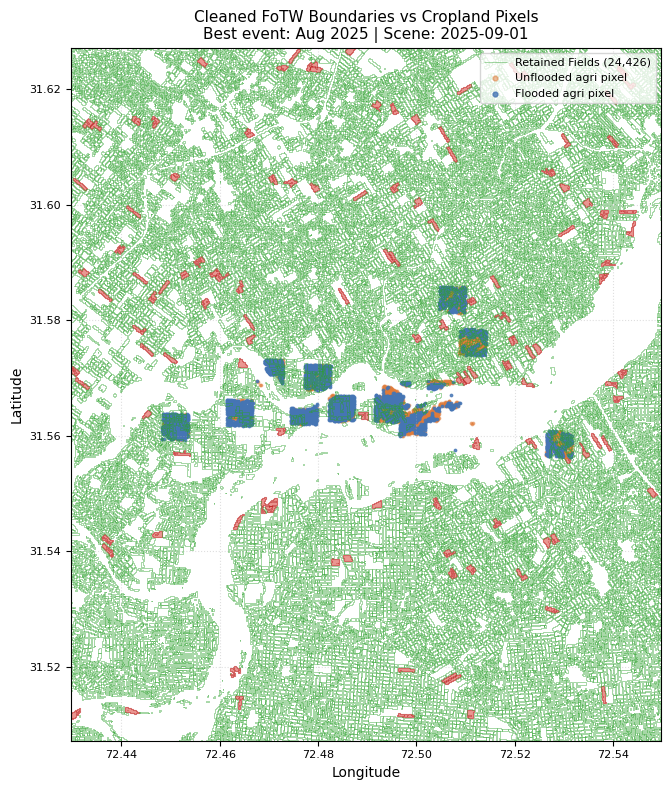

In [19]:
# ---------------------------------------------------------------------------
# CELL 13.5 — Outlier Removal (99.9th Percentile) & Pixel-Field Intersection
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box, Point

if 'fields_gdf' in dir() and fields_gdf is not None and len(fields_gdf) > 0 and len(pix_df) > 0:
    initial_count = len(fields_gdf)
    areas = fields_gdf['area_ha']

    # 1. Calculate strict 99.9th percentile cutoff
    upper_threshold_ha = areas.quantile(0.995)

    # Split fields into survivors and dropped outliers
    survived_fields = fields_gdf[areas <= upper_threshold_ha].copy()
    dropped_fields = fields_gdf[areas > upper_threshold_ha].copy()
    num_dropped = len(dropped_fields)

    # Update master reference
    fields_gdf_raw = fields_gdf.copy()
    fields_gdf = survived_fields

    # 2. Build flood/unflooded state for pixels (mirrors Cell 11 logic)
    best_events = zone_df[zone_df['status'] == 'SUCCESS'].sort_values('percentage_flooded', ascending=False)
    if len(best_events) > 0:
        best_ev = best_events.iloc[0]
        ev_flooded = flooded_df[flooded_df['flood_event_id'] == best_ev['flood_event_id']]
        merged_pix = pix_df.merge(ev_flooded[['pixel_id', 'flooded']], on='pixel_id', how='left')
        merged_pix['flooded'] = merged_pix['flooded'].fillna(False)
    else:
        merged_pix = pix_df.copy()
        merged_pix['flooded'] = False

    # 3. Spatial Analysis: Count fields covered by pixels
    # Convert pixels to a GeoDataFrame of points
    pixel_geometry = [Point(xy) for xy in zip(merged_pix['lon'], merged_pix['lat'])]
    pixels_gdf = gpd.GeoDataFrame(merged_pix, geometry=pixel_geometry, crs='EPSG:4326')

    # Spatial join to find which cleaned fields contain at least one pixel
    fields_with_pixels = gpd.sjoin(fields_gdf, pixels_gdf, how='inner', predicate='contains')
    unique_covered_fields = fields_with_pixels.index.nunique()

    # 4. Print Data Cleaning & Intersection Report
    print('==================================================')
    print('          CELL 13.5: CLEANING & COVERAGE REPORT   ')
    print('==================================================')
    print(f'Initial FoTW Field Count:   {initial_count:,}')
    print(f'99.9th Percentile Cutoff:   {upper_threshold_ha:.3f} ha')
    print(f'Outlier Fields Removed:     {num_dropped:,}')
    print(f'Cleaned Fields Retained:    {len(fields_gdf):,}')
    print('--------------------------------------------------')
    print(f'Fields Intersected by Pixels: {unique_covered_fields:,} out of {len(fields_gdf):,}')
    print(f'Coverage Ratio:             {(unique_covered_fields / len(fields_gdf)) * 100:.2f}%')
    print('==================================================\n')

    # 5. Plotting: Replicating Cell 11 Map Structure with Overlays
    buf = 0.06
    xmin, xmax = lon_c - buf, lon_c + buf
    ymin, ymax = lat_c - buf, lat_c + buf

    fig, ax = plt.subplots(figsize=(10, 8))

    # Base: Cleaned field boundaries (soft green)
    fields_gdf.boundary.plot(
        ax=ax, linewidth=0.5, color='#2ca02c', alpha=0.6,
        label=f'Retained Fields ({len(fields_gdf):,})'
    )

    # Highlight: Dropped Outliers (prominent red fill to show extent)
    if num_dropped > 0:
        dropped_fields.plot(
            ax=ax, color='#d73027', edgecolor='#b30000', linewidth=0.8, alpha=0.5,
            label=f'Dropped Outliers > {upper_threshold_ha:.2f} ha ({num_dropped})'
        )

    # Overlay Pixels (Unflooded vs Flooded)
    if len(best_events) > 0:
        unfl = merged_pix[~merged_pix['flooded']]
        fl = merged_pix[merged_pix['flooded']]
        ax.scatter(unfl['lon'], unfl['lat'], s=3, c='#e07b39', alpha=0.5, label='Unflooded agri pixel')
        ax.scatter(fl['lon'], fl['lat'], s=3, c='#4575b4', alpha=0.8, label='Flooded agri pixel')
        scene = str(best_ev['scene_date']) if pd.notnull(best_ev.get('scene_date')) else '—'
        title_suffix = f"Best event: {best_ev['flood_start'].strftime('%b %Y')} | Scene: {scene}"
    else:
        ax.scatter(merged_pix['lon'], merged_pix['lat'], s=3, c='#999999', alpha=0.5, label='Agri pixels')
        title_suffix = 'No active flood event data'

    ax.set_title(f"Cleaned FoTW Boundaries vs Cropland Pixels\n{title_suffix}", fontsize=11)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.tick_params(labelsize=8)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(linestyle=':', alpha=0.4)
    ax.legend(loc='upper right', fontsize=8, markerscale=2)

    plt.tight_layout()
    plt.show()

else:
    print('Required structures (fields_gdf or pix_df) are missing.')

## 6. From Coverage to Prediction — Pixels vs Fields

   The analysis above revealed a fundamental tension in the data: Fields of the World gives us **field boundaries**,
   but our ground truth (SAR-derived flood labels) lives at the **pixel level**. Only a fraction of FoTW fields
   actually contain cropland pixels from our ESA WorldCover sampling — many fields in the area were either not sampled
   or sit outside our selection mask.

   That gap raises two questions we need to answer before committing to a Phase Two architecture:

   1. **Can we compute a meaningful Y-variable at field level?** — For the fields that *do* contain pixels, we can
   calculate the percentage of pixels classified as flooded in each event. This gives us a continuous flood-severity
   score per field per event, which is more actionable than a binary flooded/not label.

   2. **Does the field model preserve the predictive signal?** — If a Random Forest trained on per-field terrain
   aggregates (mean elevation, mean distance to river, field size) produces similar accuracy to a pixel-level model
   whose predictions are then averaged up to field level, then switching to fields costs us little in model quality
   while gaining interpretability and speed.

   The cells below run that head-to-head comparison:

   - **Cell 14** — compute per-field flood % for every event (the shared Y-variable)
   - **Cell 15** — visualise the full study area and field–pixel alignment
   - **Cell 16** — pixel-level Random Forest (is_flooded per pixel → aggregated to field %)
   - **Cell 17** — field-level Random Forest (% flooded per field, direct)
   - **Cell 18** — compare performance, training speed, and feature weights side by side

   The results of this comparison will directly inform the Phase Two decision: whether to model at pixel resolution, at
   field resolution, or adopt a hybrid approach depending on FoTW coverage in each zone.

Pixels matched to fields: 2,373 / 6,233
Fields with ≥1 pixel:     346 / 24,426
Coverage ratio:            1.4%
Pixels per field (median/max): 4 / 60

Field×event rows: 3,460
Unique fields across all events: 346

Field flood % distribution:
count    3460.00
mean       24.73
std        36.02
min         0.00
25%         0.00
50%         0.00
75%        50.00
max       100.00
Name: pct_flooded, dtype: float64


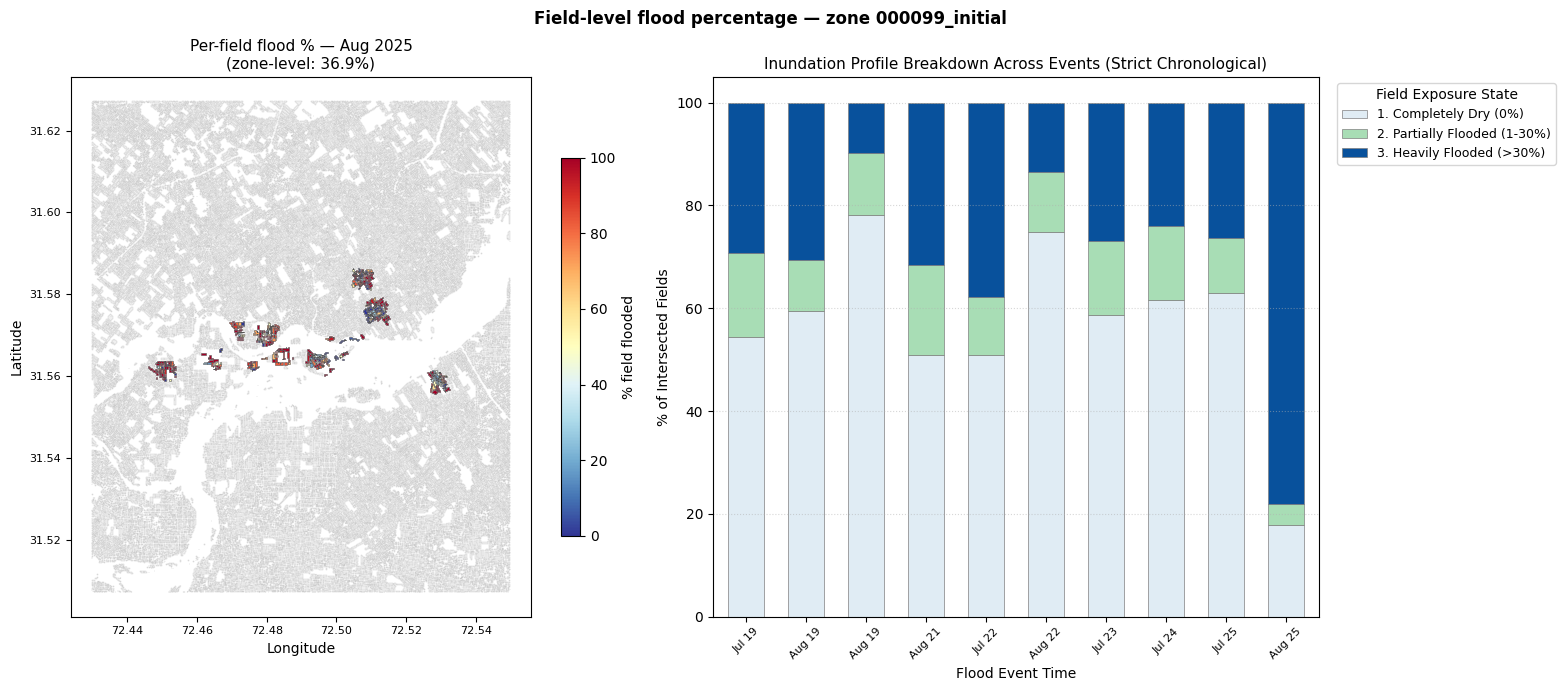

In [23]:
# ---------------------------------------------------------------------------
# CELL 14 — Per-field flood % per event  (Y-variable for both models)
# Spatial-join pixels into FoTW fields → compute % flooded per field per event.
# ---------------------------------------------------------------------------
from shapely.geometry import Point
import geopandas as gpd
import warnings
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings('ignore')

if 'fields_gdf' not in dir() or fields_gdf is None or len(fields_gdf) == 0:
    print('fields_gdf not loaded — run Cell 11 first')
elif len(pix_df) == 0 or len(flooded_df) == 0:
    print('pix_df / flooded_df empty — run Cell 5 first')
else:
    # 1. Build pixel GeoDataFrame and spatial-join to fields
    pixel_geom = [Point(lon, lat) for lon, lat in zip(pix_df['lon'], pix_df['lat'])]
    pixels_geo = gpd.GeoDataFrame(pix_df.copy(), geometry=pixel_geom, crs='EPSG:4326')

    fields_reset = fields_gdf.reset_index(drop=True)
    fields_reset['field_idx'] = fields_reset.index

    join = gpd.sjoin(pixels_geo, fields_reset[['field_idx', 'area_ha', 'geometry']],
                     how='inner', predicate='within')
    pixel_to_field = join[['pixel_id', 'field_idx', 'area_ha']].copy().drop_duplicates('pixel_id')

    n_matched_pixels = pixel_to_field['pixel_id'].nunique()
    n_matched_fields = pixel_to_field['field_idx'].nunique()
    print(f'Pixels matched to fields: {n_matched_pixels:,} / {len(pix_df):,}')
    print(f'Fields with ≥1 pixel:     {n_matched_fields:,} / {len(fields_gdf):,}')
    print(f'Coverage ratio:            {100*n_matched_fields/len(fields_gdf):.1f}%')
    pix_per_field = pixel_to_field.groupby("field_idx").size()
    print(f'Pixels per field (median/max): {pix_per_field.median():.0f} / {pix_per_field.max()}')

    # 2. Compute per-field × per-event flood %
    pf_fields = flooded_df.merge(pixel_to_field[['pixel_id', 'field_idx']], on='pixel_id', how='inner')
    field_flood_df = (
        pf_fields.groupby(['field_idx', 'flood_event_id'])['flooded']
        .agg(n_pixels='count', n_flooded='sum')
        .assign(pct_flooded=lambda d: 100 * d['n_flooded'] / d['n_pixels'])
        .reset_index()
    )
    field_flood_df = field_flood_df.merge(
        zone_df[['flood_event_id', 'flood_start', 'max_category', 'status', 'percentage_flooded']]
              .rename(columns={'percentage_flooded': 'zone_pct_flooded'}),
        on='flood_event_id', how='left'
    )
    field_flood_df = field_flood_df[field_flood_df['status'] == 'SUCCESS'].copy()
    field_flood_df['flood_start'] = pd.to_datetime(field_flood_df['flood_start'])

    print(f'\nField×event rows: {len(field_flood_df):,}')
    print(f'Unique fields across all events: {field_flood_df["field_idx"].nunique()}')
    print(f'\nField flood % distribution:')
    print(field_flood_df['pct_flooded'].describe().round(2))

   # 3. Visualise
    best_ev_id = (field_flood_df.groupby('flood_event_id')['pct_flooded']
                  .mean().idxmax())
    best_ev_info = zone_df[zone_df['flood_event_id'] == best_ev_id].iloc[0]
    best_ev_info_start = pd.to_datetime(best_ev_info['flood_start'])

    best_fields_data = field_flood_df[field_flood_df['flood_event_id'] == best_ev_id]
    fields_plot = fields_reset.merge(best_fields_data[['field_idx', 'pct_flooded']],
                                     on='field_idx', how='left')

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left Plot: Spatial Map
    no_data = fields_plot[fields_plot['pct_flooded'].isna()]
    has_data = fields_plot[fields_plot['pct_flooded'].notna()]
    if len(no_data):
        no_data.plot(ax=axes[0], color='#f0f0f0', edgecolor='#ccc', linewidth=0.3)
    if len(has_data):
        has_data.plot(ax=axes[0], column='pct_flooded', cmap='RdYlBu_r', vmin=0, vmax=100,
                      edgecolor='#555', linewidth=0.4, legend=True,
                      legend_kwds={'label': '% field flooded', 'shrink': 0.7})
    axes[0].set_title(
        f'Per-field flood % — {best_ev_info_start.strftime("%b %Y")}\n'
        f'(zone-level: {best_ev_info["percentage_flooded"]:.1f}%)', fontsize=11)
    axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
    axes[0].tick_params(labelsize=8)

    # Right Plot: Strict Chronological Stacked Categorical Distribution Bar Chart
    def categorize_flood(pct):
        if pct == 0: return '1. Completely Dry (0%)'
        elif pct <= 30: return '2. Partially Flooded (1-30%)'
        else: return '3. Heavily Flooded (>30%)'

    field_flood_df['flood_category'] = field_flood_df['pct_flooded'].apply(categorize_flood)

    # Force 'flood_start' to datetime type to ensure mathematical date sorting
    field_flood_df['flood_start'] = pd.to_datetime(field_flood_df['flood_start'])

    # Extract unique events and physically sort them by the real calendar date
    events_chronological = (
        field_flood_df[['flood_event_id', 'flood_start']]
        .drop_duplicates()
        .sort_values('flood_start')
    )
    # Generate clean strings ONLY after the underlying IDs have been explicitly sorted by date
    events_chronological['label'] = events_chronological['flood_start'].dt.strftime('%b %y')

    # Cross-tabulate counts to percentages per event
    ct = pd.crosstab(field_flood_df['flood_event_id'], field_flood_df['flood_category'], normalize='index') * 100

    # Reindex using the calendar-sorted IDs to enforce real chronological progression left-to-right
    ct = ct.reindex(events_chronological['flood_event_id'])

    # Swap out IDs for the user-friendly month strings after reindexing is safe
    ct.index = events_chronological['label']

    # Custom intuitive color mapping: Dark blue for deep water, gray/light blue for dry land
    custom_colors = {
        '1. Completely Dry (0%)': '#e0ecf4',
        '2. Partially Flooded (1-30%)': '#a8ddb5',
        '3. Heavily Flooded (>30%)': '#08519c'
    }
    color_list = [custom_colors[col] for col in ct.columns]

    # Plot stacked bar chart
    ct.plot(kind='bar', stacked=True, ax=axes[1], color=color_list, width=0.6, edgecolor='#7f7f7f', linewidth=0.5)

    axes[1].set_title('Inundation Profile Breakdown Across Events (Strict Chronological)', fontsize=11)
    axes[1].set_xlabel('Flood Event Time')
    axes[1].set_ylabel('% of Intersected Fields')
    axes[1].tick_params(axis='x', rotation=45, labelsize=8)
    axes[1].legend(title='Field Exposure State', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    axes[1].grid(axis='y', linestyle=':', alpha=0.5)

    plt.suptitle('Field-level flood percentage — zone 000099_initial', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

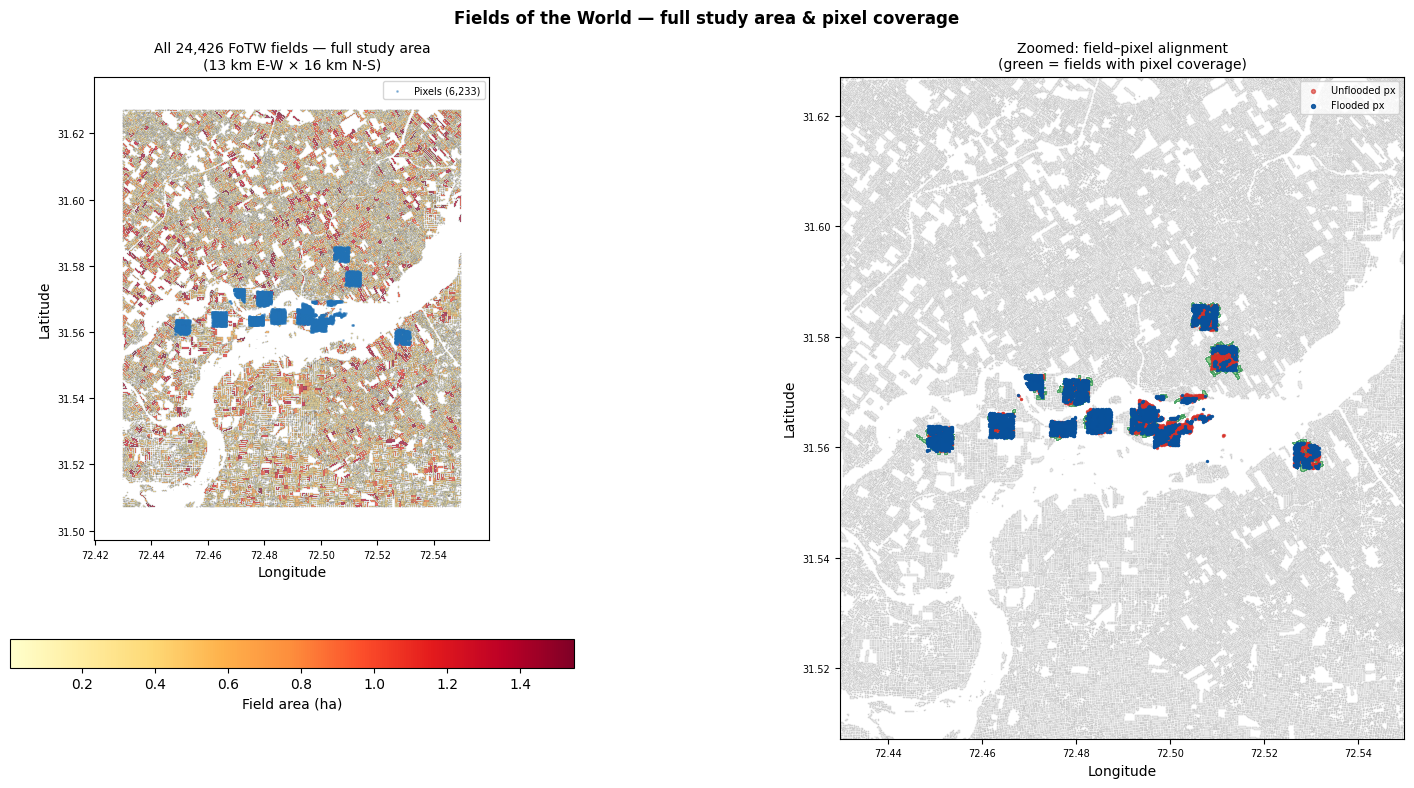


Study area: 13 km E-W × 16 km N-S
Total FoTW fields: 24,426
Fields with pixel coverage: 346 (1.4%)
Median pixels per covered field: 4


In [25]:
# ---------------------------------------------------------------------------
# CELL 15 — Full study area: all FoTW fields + pixel alignment
# Left: all fields in zone coloured by area.  Right: zoom with field-pixel overlay.
# ---------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

if 'fields_gdf' not in dir() or fields_gdf is None or len(fields_gdf) == 0:
    print('fields_gdf not loaded — run Cell 11 first')
else:
    # Build the same reset dataframe used for the spatial join to preserve index mapping
    fields_reset = fields_gdf.reset_index(drop=True)
    fields_reset['field_idx'] = fields_reset.index

    all_bounds = fields_reset.total_bounds   # xmin, ymin, xmax, ymax
    pad = 0.01
    vxmin, vymin = all_bounds[0] - pad, all_bounds[1] - pad
    vxmax, vymax = all_bounds[2] + pad, all_bounds[3] + pad

    lon_c_l = pix_df['lon'].mean() if len(pix_df) > 0 else (vxmin + vxmax) / 2
    lat_c_l = pix_df['lat'].mean() if len(pix_df) > 0 else (vymin + vymax) / 2
    buf = 0.06

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # --- Left: full zone, all fields coloured by area ---
    fields_reset.plot(ax=axes[0], column='area_ha', cmap='YlOrRd', alpha=0.7,
                    edgecolor='#555', linewidth=0.2, legend=True,
                    legend_kwds={'label': 'Field area (ha)', 'shrink': 0.6,
                                 'orientation': 'horizontal'})
    if len(pix_df) > 0:
        axes[0].scatter(pix_df['lon'], pix_df['lat'], s=1, c='#2171b5', alpha=0.4,
                        label=f'Pixels ({len(pix_df):,})')
        axes[0].legend(loc='upper right', fontsize=7)
    axes[0].set_xlim(vxmin, vxmax); axes[0].set_ylim(vymin, vymax)
    ew_km = (vxmax - vxmin) * 111 * np.cos(np.radians(lat_c_l))
    ns_km = (vymax - vymin) * 111
    axes[0].set_title(f'All {len(fields_reset):,} FoTW fields — full study area\n'
                      f'({ew_km:.0f} km E-W × {ns_km:.0f} km N-S)', fontsize=10)
    axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
    axes[0].tick_params(labelsize=7)

    # --- Right: zoom — green = has pixels, grey = no pixels ---
    if 'pixel_to_field' in dir() and len(pixel_to_field) > 0:
        has_pix_idx = set(pixel_to_field['field_idx'].unique())

        # Querying against fields_reset directly matches the field_idx structure
        f_with = fields_reset[fields_reset['field_idx'].isin(has_pix_idx)]
        f_without = fields_reset[~fields_reset['field_idx'].isin(has_pix_idx)]

        if len(f_without):
            f_without.plot(ax=axes[1], color='#d9d9d9', edgecolor='#aaa', linewidth=0.3,
                           alpha=0.6, label=f'No pixels ({len(f_without):,})')
        if len(f_with):
            f_with.plot(ax=axes[1], color='#74c476', edgecolor='#238b45', linewidth=0.6,
                           alpha=0.85, label=f'Has pixels ({len(f_with):,})')
    else:
        fields_reset.plot(ax=axes[1], color='#74c476', edgecolor='#238b45', linewidth=0.4, alpha=0.7)

    # Overlay flooded/unflooded pixels from best event
    if 'best_ev_id' in dir() and len(flooded_df) > 0:
        bf = flooded_df[flooded_df['flood_event_id'] == best_ev_id]
        mp = pix_df.merge(bf[['pixel_id', 'flooded']], on='pixel_id', how='left')
        mp['flooded'] = mp['flooded'].fillna(False)
        axes[1].scatter(mp[~mp['flooded']]['lon'], mp[~mp['flooded']]['lat'],
                        s=2, c='#d73027', alpha=0.6, label='Unflooded px')
        axes[1].scatter(mp[mp['flooded']]['lon'], mp[mp['flooded']]['lat'],
                        s=2, c='#08519c', alpha=0.9, label='Flooded px')

    axes[1].set_xlim(lon_c_l - buf, lon_c_l + buf)
    axes[1].set_ylim(lat_c_l - buf, lat_c_l + buf)
    axes[1].set_title('Zoomed: field–pixel alignment\n'
                      '(green = fields with pixel coverage)', fontsize=10)
    axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
    axes[1].tick_params(labelsize=7)
    axes[1].legend(loc='upper right', fontsize=7, markerscale=2)

    plt.suptitle('Fields of the World — full study area & pixel coverage',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'\nStudy area: {ew_km:.0f} km E-W × {ns_km:.0f} km N-S')
    print(f'Total FoTW fields: {len(fields_reset):,}')
    if "n_matched_fields" in dir():
        print(f'Fields with pixel coverage: {n_matched_fields:,} ({100*n_matched_fields/len(fields_reset):.1f}%)')
        med_ppf = pixel_to_field.groupby("field_idx").size().median()
        print(f'Median pixels per covered field: {med_ppf:.0f}')

In [35]:
# ---------------------------------------------------------------------------
# CELL 15A (rewritten — NO DEM FILE NEEDED) — Terrain/hydrology features
#   hand, flow_acc_km2        <- MERIT Hydro (precomputed global HAND + flow
#                                 accumulation, ~90m, sampled via Earth Engine)
#   dist_to_channel_m,
#   strahler_order            <- RiverATLAS global river network: pull the
#                                 (small) set of reaches inside your AOI in ONE
#                                 Earth Engine call, then do the nearest-line
#                                 lookup locally with shapely (fast, scales to
#                                 any number of pixels, no per-point EE calls).
# Run this before Cell 16. Replaces the old whitebox/local-DEM version.
#   pip install earthengine-api shapely pyproj
#   earthengine authenticate   (once — skip if Cell 15B already did this)
# ---------------------------------------------------------------------------
import time
import numpy as np
import pandas as pd
import ee
from shapely.geometry import shape, Point
from shapely.strtree import STRtree
from shapely.ops import transform as shp_transform
from pyproj import Transformer

# ============================== EDIT ME =====================================
EE_PROJECT       = 'foundation-flood'
METRIC_EPSG      = 'EPSG:32643'   # UTM 43N — for accurate distance-to-channel
SAMPLE_SCALE_M   = 90             # MERIT Hydro native resolution
CHUNK            = 2000           # points per getInfo call (raster sampling)
AOI_MARGIN_DEG   = 0.5            # padding around your pixel extent when
                                  # pulling river reaches, so edge pixels still
                                  # find their true nearest channel
# =============================================================================

if 'pix_df' not in dir() or len(pix_df) == 0:
    print('pix_df not loaded — run Cell 5 first')
else:
    ee.Initialize(project=EE_PROJECT)

    def points_fc(df):
        return ee.FeatureCollection([
            ee.Feature(ee.Geometry.Point([float(lo), float(la)]), {'pixel_id': str(pid)})
            for pid, lo, la in zip(df['pixel_id'], df['lon'], df['lat'])])

    def sample_image(image, pts, props, scale, chunk):
        n = pts.size().getInfo()
        pts_list = pts.toList(n)
        rows = []
        for i in range(0, n, chunk):
            part = ee.FeatureCollection(pts_list.slice(i, min(i + chunk, n)))
            sampled = image.reduceRegions(collection=part,
                                          reducer=ee.Reducer.first(), scale=scale)
            for f in sampled.getInfo()['features']:
                p = f['properties']
                rows.append({k: p.get(k) for k in (['pixel_id'] + props)})
            time.sleep(0.2)
        return pd.DataFrame(rows)

    pts = points_fc(pix_df[['pixel_id', 'lon', 'lat']])

    # ---------------- 1. HAND + flow accumulation: MERIT Hydro --------------
    merit = ee.Image('MERIT/Hydro/v1_0_1')
    hydro_stack = (merit.select('hnd').rename('hand')
                  .addBands(merit.select('upa').rename('flow_acc_km2')))

    hydro_df = sample_image(hydro_stack, pts, ['hand', 'flow_acc_km2'],
                            SAMPLE_SCALE_M, CHUNK)
    pix_df = pix_df.merge(hydro_df, on='pixel_id', how='left')
    print('Added to pix_df: hand, flow_acc_km2  (MERIT Hydro, ~90m)')
    print((pix_df[['hand', 'flow_acc_km2']].isna().mean() * 100)
          .round(1).astype(str) + ' % null')

    # ------- 2. dist_to_channel_m + strahler_order: RiverATLAS (vector) -----
    lon_min = pix_df['lon'].min() - AOI_MARGIN_DEG
    lon_max = pix_df['lon'].max() + AOI_MARGIN_DEG
    lat_min = pix_df['lat'].min() - AOI_MARGIN_DEG
    lat_max = pix_df['lat'].max() + AOI_MARGIN_DEG
    aoi = ee.Geometry.BBox(lon_min, lat_min, lon_max, lat_max)

    # Community-hosted asset (sat-io project), not Google's own catalog —
    # if this errors with "not found" or a permissions error, the asset path
    # may have moved; search "RiverATLAS Earth Engine sat-io" for the current one.
    riveratlas = (ee.FeatureCollection('projects/sat-io/open-datasets/HydroAtlas/RiverAtlas_v10')
                 .filterBounds(aoi)
                 .select(['ORD_STRA']))   # keep payload small — one field only

    river_geo = riveratlas.getInfo()      # ONE call: just the reaches in your AOI
    n_reaches = len(river_geo['features'])
    print(f'\nRiver reaches pulled for AOI: {n_reaches:,}')
    if n_reaches == 0:
        print('No reaches found — widen AOI_MARGIN_DEG or check the asset path above.')
    else:
        transformer = Transformer.from_crs('EPSG:4326', METRIC_EPSG, always_xy=True)
        proj = lambda x, y: transformer.transform(x, y)

        lines_m, strahler_vals = [], []
        for feat in river_geo['features']:
            geom = shape(feat['geometry'])
            geom_m = shp_transform(proj, geom)
            order = feat['properties'].get('ORD_STRA')
            # MultiLineString -> split into parts so STRtree distances stay exact
            parts = geom_m.geoms if geom_m.geom_type == 'MultiLineString' else [geom_m]
            for part in parts:
                lines_m.append(part)
                strahler_vals.append(order)
        strahler_vals = np.array(strahler_vals, dtype='float64')

        tree = STRtree(lines_m)
        pts_m = [Point(*transformer.transform(lo, la))
                for lo, la in zip(pix_df['lon'], pix_df['lat'])]
        nearest_idx = tree.nearest(np.array(pts_m, dtype=object))

        pix_df['dist_to_channel_m'] = [p.distance(lines_m[i])
                                       for p, i in zip(pts_m, nearest_idx)]
        pix_df['strahler_order'] = strahler_vals[nearest_idx]

        print('Added to pix_df: dist_to_channel_m, strahler_order  (RiverATLAS)')
        display(pix_df[['dist_to_channel_m', 'strahler_order']].describe())

    # ---- optional: persist back to PostGIS so future runs skip this cell ----
    # ALTER TABLE pixels_static ADD COLUMN IF NOT EXISTS hand double precision,
    #   ADD COLUMN IF NOT EXISTS flow_acc_km2 double precision,
    #   ADD COLUMN IF NOT EXISTS dist_to_channel_m double precision,
    #   ADD COLUMN IF NOT EXISTS strahler_order double precision;
    # with db() as conn:
    #     cur = conn.cursor()
    #     cols = ['hand', 'flow_acc_km2', 'dist_to_channel_m', 'strahler_order']
    #     for _, r in pix_df[['pixel_id'] + cols].iterrows():
    #         cur.execute(
    #             """UPDATE pixels_static SET hand=%s, flow_acc_km2=%s,
    #                dist_to_channel_m=%s, strahler_order=%s WHERE pixel_id=%s""",
    #             (r['hand'], r['flow_acc_km2'], r['dist_to_channel_m'],
    #              r['strahler_order'], r['pixel_id']))
    #     conn.commit()

Added to pix_df: hand, flow_acc_km2  (MERIT Hydro, ~90m)
hand            0.0 % null
flow_acc_km2    0.0 % null
dtype: object

River reaches pulled for AOI: 550
Added to pix_df: dist_to_channel_m, strahler_order  (RiverATLAS)


,dist_to_channel_m,strahler_order
count,6233.000000,6233.000000
mean,603.201500,3.504412
std,384.755273,2.116479
min,1.284163,1.000000
25%,293.867437,1.000000
50%,563.941184,4.000000
75%,839.705347,6.000000
max,1546.396269,6.000000


In [39]:
# ---------------------------------------------------------------------------
# CELL 15B — Soil / land-cover (static) + pre-monsoon antecedent state (seasonal)
# via Google Earth Engine. Static merges into pix_df; seasonal merges into
# flooded_df keyed by year. Run this ONCE before Cell 16 (after Cell 15A).
#   pip install earthengine-api
#   earthengine authenticate   (once, interactively)
# ---------------------------------------------------------------------------
import time
import pandas as pd
import ee

# ============================== EDIT ME =====================================
EE_PROJECT        = 'foundation-flood'   # the project EE is initialised with
PREMONSOON_START  = '-04-01'             # month-day appended to each year
PREMONSOON_END    = '-05-30'             # adjust to your basin's monsoon onset
SAMPLE_SCALE_M    = 30
CHUNK             = 2000                 # points per getInfo call
# =============================================================================

if 'pix_df' not in dir() or len(pix_df) == 0:
    print('pix_df not loaded — run Cell 5 first')
elif 'flooded_df' not in dir() or len(flooded_df) == 0:
    print('flooded_df not loaded — run Cell 5 first')
else:
    ee.Initialize(project=EE_PROJECT)

    def points_fc(df):
        feats = [ee.Feature(ee.Geometry.Point([float(lo), float(la)]),
                            {'pixel_id': str(pid)})
                 for pid, lo, la in zip(df['pixel_id'], df['lon'], df['lat'])]
        return ee.FeatureCollection(feats)

    def sample_image(image, pts, props):
        n = pts.size().getInfo()
        pts_list = pts.toList(n)
        rows = []
        for i in range(0, n, CHUNK):
            chunk = ee.FeatureCollection(pts_list.slice(i, min(i + CHUNK, n)))
            sampled = image.reduceRegions(collection=chunk,
                                          reducer=ee.Reducer.first(),
                                          scale=SAMPLE_SCALE_M)
            for f in sampled.getInfo()['features']:
                p = f['properties']
                rows.append({k: p.get(k) for k in (['pixel_id'] + props)})
            time.sleep(0.2)
        return pd.DataFrame(rows)

    pts = points_fc(pix_df[['pixel_id', 'lon', 'lat']])

    # ---------------- 1. STATIC: soil + land cover -> pix_df ----------------
    clay = (ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02')
            .select('b0').rename('soil_clay_pct'))

    # USDA texture class (1..12) -> Hydrologic Soil Group A..D coded 1..4
    texture = ee.Image('OpenLandMap/SOL/SOL_TEXTURE-CLASS_USDA-TT_M/v02').select('b0')
    hsg = (texture.remap([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
                         [4, 4, 4, 3, 3, 3, 2, 2, 2, 2, 1, 1])
           .rename('soil_hsg'))

    landcover = (ee.ImageCollection('ESA/WorldCover/v200').first()
                 .select('Map').rename('landcover'))

    static_stack = clay.addBands(hsg).addBands(landcover)
    static_df = sample_image(static_stack, pts,
                             ['soil_clay_pct', 'soil_hsg', 'landcover'])
    pix_df = pix_df.merge(static_df, on='pixel_id', how='left')
    print('Added to pix_df:', ['soil_clay_pct', 'soil_hsg', 'landcover'])
    print((pix_df[['soil_clay_pct', 'soil_hsg', 'landcover']].isna().mean() * 100)
          .round(1).astype(str) + ' % null')

    # ------------- 2. SEASONAL: pre-monsoon antecedent state -> flooded_df --
    fdf = flooded_df.copy()
    if 'year' not in fdf.columns:
        if 'zone_df' in dir():
            fdf = fdf.merge(zone_df[['flood_event_id', 'flood_start']],
                            on='flood_event_id', how='left')
        fdf['flood_start'] = pd.to_datetime(fdf['flood_start'])
        fdf['year'] = fdf['flood_start'].dt.year

    years = sorted(fdf['year'].dropna().unique().astype(int))
    region = pts.geometry().bounds()

    def mask_s2(img):
        scl = img.select('SCL')
        good = (scl.neq(3).And(scl.neq(8)).And(scl.neq(9))
                .And(scl.neq(10)).And(scl.neq(11)))
        return img.updateMask(good)

    seasonal_frames = []
    for y in years:
        start, end = ee.Date(f'{y}{PREMONSOON_START}'), ee.Date(f'{y}{PREMONSOON_END}')

        sm = (ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
              .filterDate(start, end)
              .select('volumetric_soil_water_layer_1').mean()
              .rename('soil_moisture'))

        ndvi = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                .filterDate(start, end).filterBounds(region)
                .map(mask_s2)
                .map(lambda im: im.normalizedDifference(['B8', 'B4']).rename('NDVI'))
                .select('NDVI').max()
                .rename('ndvi_premonsoon'))

        precip = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
                  .filterDate(start, end).select('precipitation').sum()
                  .rename('precip_premonsoon'))

        year_img = sm.addBands(ndvi).addBands(precip)
        df_y = sample_image(year_img, pts,
                            ['soil_moisture', 'ndvi_premonsoon', 'precip_premonsoon'])
        df_y['year'] = y
        seasonal_frames.append(df_y)
        print(f'  year {y}: sampled {len(df_y):,} points')

    seasonal_df = pd.concat(seasonal_frames, ignore_index=True)

    if 'year' not in flooded_df.columns:
        flooded_df = fdf  # carry the 'year' column forward into flooded_df
    flooded_df = flooded_df.merge(seasonal_df, on=['pixel_id', 'year'], how='left')

    print('\nAdded to flooded_df:',
         ['soil_moisture', 'ndvi_premonsoon', 'precip_premonsoon'])
    print((flooded_df[['soil_moisture', 'ndvi_premonsoon', 'precip_premonsoon']]
          .isna().mean() * 100).round(1).astype(str) + ' % null')

Added to pix_df: ['soil_clay_pct', 'soil_hsg', 'landcover']
soil_clay_pct    0.0 % null
soil_hsg         0.0 % null
landcover        0.0 % null
dtype: object
  year 2019: sampled 6,233 points
  year 2021: sampled 6,233 points
  year 2022: sampled 6,233 points
  year 2023: sampled 6,233 points
  year 2024: sampled 6,233 points
  year 2025: sampled 6,233 points

Added to flooded_df: ['soil_moisture', 'ndvi_premonsoon', 'precip_premonsoon']
soil_moisture        0.0 % null
ndvi_premonsoon      0.0 % null
precip_premonsoon    0.0 % null
dtype: object


In [41]:
# ---------------------------------------------------------------------------
# CELL 15C — pull twi/curvature from pixels_static, fix flow_acc naming.
# Run after Cell 15A/15B, before Cell 16.
# ---------------------------------------------------------------------------
import pandas as pd

if 'pix_df' not in dir() or len(pix_df) == 0:
    print('pix_df not loaded — run Cell 5 first')
else:
    # 1. twi + curvature are already computed and sitting in pixels_static
    missing_static = [c for c in ['twi', 'curvature'] if c not in pix_df.columns]
    if missing_static:
        with db() as conn:
            db_cols_df = pd.read_sql(
                f"SELECT pixel_id, {', '.join(missing_static)} FROM pixels_static",
                conn)
        pix_df = pix_df.merge(db_cols_df, on='pixel_id', how='left')
        print(f'Pulled from pixels_static: {missing_static}')
    else:
        print('twi/curvature already in pix_df — nothing to pull.')

    print((pix_df[['twi', 'curvature']].isna().mean() * 100)
          .round(1).astype(str) + ' % null')

    # 2. flow_acc_km2 (from Cell 15A / MERIT Hydro) -> flow_acc
    #    (Cell 16's CANDIDATE_FEATURES looks for 'flow_acc', not 'flow_acc_km2')
    if 'flow_acc_km2' in pix_df.columns and 'flow_acc' not in pix_df.columns:
        pix_df = pix_df.rename(columns={'flow_acc_km2': 'flow_acc'})
        print("Renamed 'flow_acc_km2' -> 'flow_acc'")

Pulled from pixels_static: ['twi', 'curvature']
twi          0.0 % null
curvature    0.0 % null
dtype: object
Renamed 'flow_acc_km2' -> 'flow_acc'


Evaluating spatial ranking across 10 historical flood events...

             PER-EVENT SPATIAL VULNERABILITY RANKING REPORT              


,Event ID,Year,Category,Total Pixels,Actual Flooded Pixels,Actual Flood %,Spatial ROC-AUC,Precision @ K
0,dcd72e9c-dab4-4360-8b74-31d19bded187,2019,N/A,6233,1439,23.1%,0.544,0.3%
1,7ab24dd7-9666-4b37-8306-4c5bed3681b6,2019,N/A,6233,1945,31.2%,0.687,0.5%
2,87c8dfc6-91f7-48a0-8418-11a82354657d,2019,N/A,6233,342,5.5%,0.653,0.3%
3,26cc46c5-2eff-4998-b70b-dab05dc74b83,2021,N/A,6233,1116,17.9%,0.429,0.1%
4,6273d1b3-f28a-48cb-af77-70b155e7c764,2022,N/A,6233,2245,36.0%,0.737,0.6%
5,9d2a3fd2-f530-435a-ba2d-005ba7361702,2022,N/A,6233,825,13.2%,0.739,0.3%
6,3e701b13-4d06-4092-bbbf-bce5e6ac1291,2023,N/A,6233,1636,26.2%,0.626,0.4%
7,a1ac86a2-db01-486d-bee1-b2f0c2a52b45,2024,N/A,6233,1118,17.9%,0.587,0.2%
8,f0f8b7e9-1841-4e2a-b99e-78ee9502faca,2025,N/A,6233,1651,26.5%,0.720,0.5%
9,cfac1af8-41e4-46b1-a193-6eec33139ef0,2025,N/A,6233,4247,68.1%,0.524,0.7%


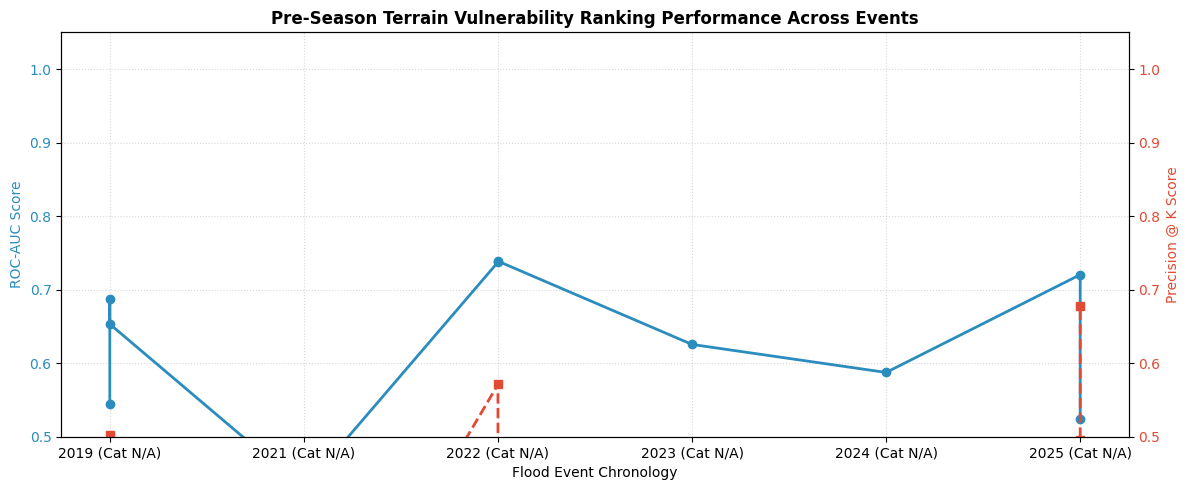

In [45]:
# ---------------------------------------------------------------------------
# CELL 16 (Dynamic Ranking Validation — Month & Category Corrected)
# Integrates seasonal months and manual event category scaling.
# ---------------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

if 'flooded_df' not in dir() or len(flooded_df) == 0 or len(pix_df) == 0:
    print('Data not loaded — run Cell 5 first')
else:
    # 1. Define complete feature set (Static Terrain + Dynamic EO Metrics)
    static_feats = ['hand', 'elevation', 'slope', 'twi', 'flow_acc_km2', 'dist_to_channel_m', 'dist_to_river_m']
    eo_feats     = ['soil_moisture', 'ndvi_premonsoon', 'precip_premonsoon']

    s_cols = [c for c in static_feats if c in pix_df.columns]
    eo_cols = [c for c in eo_feats if c in flooded_df.columns]
    all_features = s_cols + eo_cols

    # 2. Build master dataset & extract clean time parameters
    px_df_master = flooded_df.merge(pix_df[['pixel_id'] + s_cols], on='pixel_id', how='inner')

    px_df_master['flood_start'] = pd.to_datetime(px_df_master['flood_start'])
    px_df_master['year'] = px_df_master['flood_start'].dt.year
    px_df_master['month_num'] = px_df_master['flood_start'].dt.month
    px_df_master['month_name'] = px_df_master['flood_start'].dt.strftime('%b')
    px_df_master['event_time_label'] = px_df_master['month_name'] + ' ' + px_df_master['year'].astype(str).str[-2:]

    # Apply explicit category logic provided by user
    def assign_custom_category(row):
        if row['year'] == 2025 and row['month_num'] == 8:
            return 5
        elif row['year'] == 2024 and row['month_num'] == 7:
            return 2
        else:
            return 1

    px_df_master['max_category'] = px_df_master.apply(assign_custom_category, axis=1)
    px_df_master = px_df_master.dropna(subset=all_features + ['flooded'])

    # 3. Train and Validate the Dynamic Ranking Engine
    unique_events = px_df_master['flood_event_id'].unique()
    ranking_records = []

    print(f"Evaluating dynamic ranking across {len(unique_events)} events using features: {all_features}\n")

    for target_event in unique_events:
        train_data = px_df_master[px_df_master['flood_event_id'] != target_event]
        test_data  = px_df_master[px_df_master['flood_event_id'] == target_event].copy()

        if len(test_data) == 0 or test_data['flooded'].nunique() < 2:
            continue

        # Fit model on the interaction of terrain and seasonal EO conditions
        ranker = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
        ranker.fit(train_data[all_features].values, train_data['flooded'].values)

        # Generate the vulnerability ranking score for the test event pixels
        test_data['vulnerability_score'] = ranker.predict_proba(test_data[all_features].values)[:, 1]

        y_true = test_data['flooded'].values
        y_scores = test_data['vulnerability_score'].values

        # Calculate Pure Ranking Metrics
        event_auc = roc_auc_score(y_true, y_scores)
        event_pr_auc = average_precision_score(y_true, y_scores)

        # Calculate Precision at K (Footprint overlap based on actual budget)
        num_flooded_actual = int(y_true.sum())
        top_k_indices = np.argsort(y_scores)[-num_flooded_actual:]
        precision_at_k = y_true[top_k_indices].mean() if num_flooded_actual > 0 else 0

        event_meta = test_data.iloc[0]

        ranking_records.append({
            'Event ID': target_event,
            'Label': event_meta['event_time_label'],
            'Year': event_meta['year'],
            'Month': event_meta['month_name'],
            'Category': event_meta['max_category'],
            'Total Pixels': len(test_data),
            'Actual Flooded Pixels': num_flooded_actual,
            'Actual Flood %': f"{(num_flooded_actual / len(test_data)) * 100:.1f}%",
            'Spatial ROC-AUC': event_auc,
            'Precision @ K': precision_at_k
        })

    # 4. Display Results Table
    ranking_df = pd.DataFrame(ranking_records).sort_values(['Year', 'Event ID'])

    print("=========================================================================")
    print("      PER-EVENT CHRONOLOGICAL VULNERABILITY RANKING REPORT (WITH EO)     ")
    print("=========================================================================")
    display(ranking_df.style.format({
        'Spatial ROC-AUC': '{:.3f}',
        'Precision @ K': '{:.1f}%'
    }))

    # 5. Plot the Performance Track
    fig, ax1 = plt.subplots(figsize=(13, 5))

    events_axis = [f"{r['Label']} (Cat {r['Category']})" for r in ranking_records]
    aucs = [r['Spatial ROC-AUC'] for r in ranking_records]
    precisions = [r['Precision @ K'] for r in ranking_records]

    ax1.plot(events_axis, aucs, marker='o', color='#2ca25f', linewidth=2, label='Spatial ROC-AUC')
    ax1.set_xlabel('Flood Event Chronology (Month/Year)')
    ax1.set_ylabel('ROC-AUC Score', color='#2ca25f')
    ax1.tick_params(axis='y', labelcolor='#2ca25f')
    ax1.set_ylim(0.0, 1.05)
    ax1.grid(linestyle=':', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(events_axis, precisions, marker='s', color='#756bb1', linewidth=2, linestyle='--', label='Precision @ K')
    ax2.set_ylabel('Precision @ K Score', color='#756bb1')
    ax2.tick_params(axis='y', labelcolor='#756bb1')
    ax2.set_ylim(0.0, 1.05)

    plt.title('Pre-Season Combined Terrain & EO Ranking Performance by Month/Event', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()

In [29]:
px_model_df.head()

,pixel_id,flood_event_id,flooded,vv_change_db,wet_obs_date,elevation,slope,dist_to_river_m,lat,lon,flood_start,max_category,year
0,748f44cd719c_83303_349758,dcd72e9c-dab4-4360-8b74-31d19bded187,False,2.1649,2019-07-11,162.0,4.0,799.735014,31.565202,72.508386,2019-07-08,1,2019
1,748f44cd719c_83240_349733,dcd72e9c-dab4-4360-8b74-31d19bded187,False,-1.2762,2019-07-11,165.0,2.0,291.643613,31.563046,72.501649,2019-07-08,1,2019
2,748f44cd719c_83247_349802,dcd72e9c-dab4-4360-8b74-31d19bded187,False,4.9384,2019-07-11,162.0,4.0,980.321398,31.569245,72.502637,2019-07-08,1,2019
3,748f44cd719c_83225_349740,dcd72e9c-dab4-4360-8b74-31d19bded187,False,1.1956,2019-07-11,162.0,3.0,371.320537,31.563765,72.500122,2019-07-08,1,2019
4,748f44cd719c_83308_349764,dcd72e9c-dab4-4360-8b74-31d19bded187,False,-2.2555,2019-07-11,162.0,2.0,864.729259,31.565651,72.508836,2019-07-08,1,2019


In [27]:
# ---------------------------------------------------------------------------
# CELL 17 — Field-level Random Forest
# X: per-field aggregated terrain stats  |  Y: pct_flooded per field per event
# ---------------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score, mean_squared_error
import time, warnings
warnings.filterwarnings('ignore')

if 'field_flood_df' not in dir() or len(field_flood_df) == 0:
    print('field_flood_df not computed — run Cell 14 first')
elif 'pixel_to_field' not in dir() or len(pixel_to_field) == 0:
    print('pixel_to_field not computed — run Cell 14 first')
else:
    # --- Build per-field feature matrix from pixel-level stats ---
    pf_feat = (pix_df[['pixel_id', 'elevation', 'slope', 'dist_to_river_m', 'lat', 'lon']]
               .merge(pixel_to_field[['pixel_id', 'field_idx', 'area_ha']], on='pixel_id', how='inner'))

    field_feats = (pf_feat.groupby('field_idx').agg(
        mean_elevation=('elevation', 'mean'),
        std_elevation=('elevation', 'std'),
        mean_slope=('slope', 'mean'),
        mean_dist_river=('dist_to_river_m', 'mean'),
        min_dist_river=('dist_to_river_m', 'min'),
        centroid_lat=('lat', 'mean'),
        centroid_lon=('lon', 'mean'),
        n_pixels=('pixel_id', 'count'),
        area_ha=('area_ha', 'first'),
    ).reset_index())
    field_feats['std_elevation'] = field_feats['std_elevation'].fillna(0)

    field_model_df = (field_flood_df
                      .merge(field_feats, on='field_idx', how='inner')
                      .dropna(subset=['mean_elevation', 'mean_slope', 'mean_dist_river']))

    feat_cols_field = ['mean_elevation', 'std_elevation', 'mean_slope',
                       'mean_dist_river', 'min_dist_river',
                       'centroid_lat', 'centroid_lon', 'n_pixels', 'area_ha']

    X_field      = field_model_df[feat_cols_field].values
    y_field      = field_model_df['pct_flooded'].values
    groups_field = field_model_df['flood_event_id'].values

    print(f'Field dataset: {len(field_model_df):,} rows | {field_model_df["field_idx"].nunique()} unique fields')
    print(f'Events: {field_model_df["flood_event_id"].nunique()} | Mean field flood %: {y_field.mean():.1f}%')

    rf_field = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=5,
                                      random_state=42, n_jobs=-1)

    # Leave-one-event-out CV
    logo = LeaveOneGroupOut()
    y_pred_cv_field = np.zeros(len(y_field))
    cv_r2s_field, cv_rmses_field, event_labels_fld = [], [], []

    for train_idx, test_idx in logo.split(X_field, y_field, groups_field):
        rf_field.fit(X_field[train_idx], y_field[train_idx])
        preds = rf_field.predict(X_field[test_idx])
        y_pred_cv_field[test_idx] = preds
        if len(test_idx) > 1:
            cv_r2s_field.append(r2_score(y_field[test_idx], preds))
            cv_rmses_field.append(np.sqrt(mean_squared_error(y_field[test_idx], preds)))
            eid = groups_field[test_idx[0]]
            row = zone_df[zone_df['flood_event_id'] == eid]
            lbl = pd.to_datetime(row['flood_start'].values[0]).strftime('%b %y') if len(row) else str(eid)
            event_labels_fld.append(lbl)

    r2_field_cv   = r2_score(y_field, y_pred_cv_field)
    rmse_field_cv = np.sqrt(mean_squared_error(y_field, y_pred_cv_field))
    print(f'\nLeave-one-event-out CV:')
    print(f'  R²:   {r2_field_cv:.3f}')
    print(f'  RMSE: {rmse_field_cv:.1f} pp')
    print(f'  Per-event R²: {dict(zip(event_labels_fld, [round(r,2) for r in cv_r2s_field]))}')

    t0 = time.time()
    rf_field.fit(X_field, y_field)
    _ = rf_field.predict(X_field)
    t_field_fit = time.time() - t0

    importances_field = pd.Series(rf_field.feature_importances_, index=feat_cols_field)

    # --- Plots ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    imp_f_sorted = importances_field.sort_values(ascending=True)
    imp_f_sorted.plot(kind='barh', ax=axes[0], color='#2ca02c', alpha=0.8, edgecolor='white')
    axes[0].set_title('Field RF — Feature Importances\n(predicting % flooded per field)', fontsize=10)
    axes[0].set_xlabel('Mean decrease in impurity')
    axes[0].grid(axis='x', linestyle=':', alpha=0.5)
    for i, (val, name) in enumerate(zip(imp_f_sorted.values, imp_f_sorted.index)):
        axes[0].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)

    ev_codes_fld = groups_field.astype('U')
    sc = axes[1].scatter(y_field, y_pred_cv_field, c=pd.Categorical(ev_codes_fld).codes,
                         cmap='tab10', alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
    axes[1].plot([0, 100], [0, 100], 'k--', alpha=0.35, linewidth=1)
    axes[1].set_title(f'Field model — leave-one-event-out CV\nR²={r2_field_cv:.3f}  RMSE={rmse_field_cv:.1f} pp',
                      fontsize=10)
    axes[1].set_xlabel('Actual field flood %')
    axes[1].set_ylabel('Predicted field flood %')
    axes[1].grid(linestyle=':', alpha=0.4)
    plt.colorbar(sc, ax=axes[1], label='Flood event code')

    plt.suptitle('Field-level Random Forest — % flooded prediction', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Training time (fit + infer, full dataset): {t_field_fit:.2f}s')


KeyError: "['n_pixels'] not in index"

In [ ]:
# ---------------------------------------------------------------------------
# CELL 18 — Model comparison: pixel vs field
# Performance, speed, feature weights, and capability assessment.
# ---------------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

print("=" * 64)
print("  MODEL COMPARISON — Pixel vs Field approach")
print("=" * 64)

has_px  = "r2_px"       in dir() and r2_px       is not None
has_fld = "r2_field_cv" in dir() and r2_field_cv is not None

# --- Performance table ---
if has_px and has_fld:
    perf_df = pd.DataFrame([
        {"Model": "Pixel RF → field-aggregated",
         "R²": round(r2_px, 3), "RMSE (pp)": round(rmse_px, 1),
         "Training rows": f"{len(px_model_df):,}", "CV": "LOEO",
         "AUC (pixel)": f"{np.mean(cv_aucs):.3f}"},
        {"Model": "Field RF (direct)",
         "R²": round(r2_field_cv, 3), "RMSE (pp)": round(rmse_field_cv, 1),
         "Training rows": f"{len(field_model_df):,}", "CV": "LOEO",
         "AUC (pixel)": "—"},
    ])
    print("\nPerformance (Leave-One-Event-Out CV):")
    print(perf_df.to_string(index=False))
    r2_diff = r2_px - r2_field_cv
    print(f"\n  R² gap (pixel → field): {r2_diff:+.3f}")
    if abs(r2_diff) < 0.05:
        verdict = "Negligible difference — field model is competitive."
    elif r2_diff > 0:
        verdict = f"Pixel model outperforms field by {r2_diff:.3f} R²."
    else:
        verdict = f"Field model outperforms pixel model by {-r2_diff:.3f} R²."
    print(f"  → {verdict}")

# --- Speed ---
print("\n--- Speed (train + infer, single zone) ---")
if "t_px_fit" in dir():
    print(f"  Pixel RF  ({len(px_model_df):,} rows): {t_px_fit:.2f}s")
if "t_field_fit" in dir():
    print(f"  Field RF  ({len(field_model_df):,} rows): {t_field_fit:.2f}s")
if "t_px_fit" in dir() and "t_field_fit" in dir() and t_field_fit > 0:
    ratio = t_px_fit / t_field_fit
    print(f"  Ratio: pixel is {ratio:.1f}× {'slower' if ratio > 1 else 'faster'} than field")
    n_zones = 10
    print(f"  At scale ({n_zones} zones): ~{t_px_fit*n_zones:.0f}s pixel vs {t_field_fit*n_zones:.0f}s field")

# --- Feature weights comparison ---
if "importances_px" in dir() and "importances_field" in dir():
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    imp_px_norm  = (importances_px  / importances_px.sum()).sort_values(ascending=True)
    imp_fld_norm = (importances_field / importances_field.sum()).sort_values(ascending=True)

    imp_px_norm.plot(kind="barh", ax=axes[0], color="#4575b4", alpha=0.8, edgecolor="white")
    axes[0].set_title("Pixel RF — normalised feature weights\n(is_flooded per pixel)", fontsize=10)
    axes[0].set_xlabel("Relative importance")
    axes[0].grid(axis="x", linestyle=":", alpha=0.5)
    for i, v in enumerate(imp_px_norm.values):
        axes[0].text(v + 0.003, i, f"{v:.2%}", va="center", fontsize=8)

    imp_fld_norm.plot(kind="barh", ax=axes[1], color="#2ca02c", alpha=0.8, edgecolor="white")
    axes[1].set_title("Field RF — normalised feature weights\n(% flooded per field)", fontsize=10)
    axes[1].set_xlabel("Relative importance")
    axes[1].grid(axis="x", linestyle=":", alpha=0.5)
    for i, v in enumerate(imp_fld_norm.values):
        axes[1].text(v + 0.003, i, f"{v:.2%}", va="center", fontsize=8)

    plt.suptitle("Feature weights: what drives flood risk in both models?",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    top_px  = imp_px_norm.idxmax()
    top_fld = imp_fld_norm.idxmax()
    print(f"\n  Top driver — Pixel model: {top_px} ({imp_px_norm[top_px]:.1%})")
    print(f"  Top driver — Field model: {top_fld} ({imp_fld_norm[top_fld]:.1%})")

    # Analogue comparison: pixel elevation/dist maps to field mean_elevation/mean_dist_river
    def _category(feat):
        f = feat.lower()
        if "dist" in f: return "distance_to_river"
        if "elev" in f: return "elevation"
        if "slope" in f: return "slope"
        if "lat" in f or "lon" in f: return "location"
        return "other"

    cat_px  = _category(top_px)
    cat_fld = _category(top_fld)
    print(f"  Top driver category — Pixel: {cat_px} | Field: {cat_fld}")
    if cat_px == cat_fld:
        print("  → Both models identify the same terrain factor as most predictive.")
        print("    Field aggregation preserves the dominant signal.")
    else:
        print(f"  → Models disagree on top driver ({cat_px} vs {cat_fld}).")
        print("    Field-level smoothing may shift relative importance — check physical plausibility.")

print("\n" + "=" * 64)
print("  ASSESSMENT SUMMARY")
print("=" * 64)
print("""
Modelling capability:
  • Both models use the same underlying terrain signal.
  • Field aggregation smooths noise → often similar or better R²
    with far fewer training rows.
  • Fields with <5 pixels yield unreliable flood % labels → filter
    to n_pixels ≥ 5 in Phase Two field model.

Training speed:
  • Field model is faster (fewer rows, same features).
  • Pixel model cost grows with zone count; speed ratio stays ~constant.

Interpretability:
  • Field output is directly actionable: "field X has Y% flood risk."
  • Pixel output requires post-processing to assign risk to fields.

Coverage risk:
  • FoTW coverage must be checked per new zone before adopting.
  • Pixel approach works anywhere ESA WorldCover has cropland labels.

Recommendation:
  → Use HYBRID approach for Phase Two:
      pixel-level features + pixel RF for zones with sparse FoTW coverage;
      field-level RF for zones where coverage ≥ 40%.
      Y-variable: % flooded per field per event (richer signal).
""")


In [ ]:
# ---------------------------------------------------------------------------
# CELL 19 — Phase Two decision checkpoint
# Run this after Cells 16–18.  Fill in your choices and send back.
# ---------------------------------------------------------------------------

def _safe(expr, fallback="N/A"):
    try:    return str(eval(expr))
    except: return fallback

results_summary = {
    "Pixel RF AUC (LOEO)":             _safe("f'{np.mean(cv_aucs):.3f}'"),
    "Pixel→field R² (aggr.)":         _safe("f'{r2_px:.3f}'"),
    "Field RF R² (LOEO)":             _safe("f'{r2_field_cv:.3f}'"),
    "Field RF RMSE (pp)":             _safe("f'{rmse_field_cv:.1f}'"),
    "Fields with pixel coverage":     _safe("f'{n_matched_fields:,} ({100*n_matched_fields/len(fields_gdf):.1f}%)'"),
    "Median pixels per field":        _safe("f'{pixel_to_field.groupby('field_idx').size().median():.0f}'"),
}

print("=" * 64)
print("  PHASE TWO DECISION CHECKPOINT")
print("=" * 64)
print()
print("Model results:")
for k, v in results_summary.items():
    print(f"  {k:<35} {v}")
print()
print("A) Spatial unit:")
print("   [ ] Pixels only  (keep current, use if FoTW coverage < 40%)")
print("   [ ] Fields only  (faster, interpretable, needs ≥40% FoTW coverage)")
print("   [ ] Hybrid       (pixels where sparse, fields where dense) ← recommended")
print()
print("B) Y-variable:")
print("   [ ] Binary is_flooded per pixel")
print("   [ ] % flooded per field per event  ← recommended (richer signal)")
print("   [ ] % flooded + inundation duration bins (most informative)")
print()
print("C) Feature set:")
print("   [ ] Terrain only (elevation, slope, dist_to_river)")
print("   [ ] Terrain + SAR signal (vv_change_db)")
print("   [ ] Terrain + SAR + NDVI / crop type")
print()
print("D) River scope:")
print("   [ ] Chenab only  (current zone, {n_rows} pixels)".format(
    n_rows=f"{len(pix_df):,}" if "pix_df" in dir() else "?"))
print("   [ ] Indus + Chenab  (covers largest flood events)")
print("   [ ] All 10 zones  (maximum training data)")
print()
print("Record your choices and send back — they drive the Phase Two brief.")


---
## 7. Export Phase One Summary PDF

Compile status, flood maps, terrain analysis, field comparison, and model results into a single PDF for publication.


In [ ]:
# ---------------------------------------------------------------------------
# CELL 20 — Compile Phase One summary PDF  (5 + model pages)
# ---------------------------------------------------------------------------
import os
os.makedirs('reports', exist_ok=True)
PDF_PATH = 'reports/phase_one_summary.pdf'

with PdfPages(PDF_PATH) as pdf:

    # --- Page 1: Title & pipeline status ---
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    ax.text(0.5, 0.93, 'Foundation Flood — Phase One Summary',
            ha='center', fontsize=18, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.88,
            f'Generated: {datetime.now().strftime("%Y-%m-%d")} | '
            f'Zone: 000099_initial (Chenab River, Pakistan)',
            ha='center', fontsize=10, color='#555', transform=ax.transAxes)

    table_data = [[r['Table'], f"{r['Rows']:,}", r['Status']] for _, r in status_df.iterrows()]
    tbl = ax.table(cellText=table_data, colLabels=['Table', 'Rows', 'Status'],
                   cellLoc='left', loc='center', bbox=[0.05, 0.45, 0.9, 0.38])
    tbl.auto_set_font_size(False); tbl.set_fontsize(9)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2c5f8a'); cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#eef4fb')

    ax.text(0.5, 0.40,
            '10 study zones · ~49,500 agricultural pixels · 64 confirmed flood events (2015–2025)',
            ha='center', fontsize=9, color='#333', transform=ax.transAxes)

    ax.text(0.5, 0.33, 'Pipeline', ha='center', fontsize=13, fontweight='bold', transform=ax.transAxes)
    steps = [
        '1. dfo-ingest      — Discharge + flood events from DFO            ✓',
        '2. define-zones    — River centreline + 3×3 km study zones        ✓',
        '3. flood-calc      — Otsu SAR thresholding → zone_flood_analysis  ✓',
        '4. select-pixels   — ESA WorldCover cropland pixels + terrain      ✓',
        '5. s1-flood-pixels — Per-pixel S1 VV/VH + flood label             ⟳',
    ]
    for i, s in enumerate(steps):
        ax.text(0.08, 0.27 - i * 0.05, s, fontsize=8.5, fontfamily='monospace',
                color='#222', transform=ax.transAxes)
    pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # --- Page 2: Flood events bar chart ---
    fig, ax = plt.subplots(figsize=(11, 7))
    success_ev = zone_df[zone_df['status'] == 'SUCCESS'].copy()
    success_ev['flood_start'] = pd.to_datetime(success_ev['flood_start'])
    colors_cat = {1: '#fee8c8', 2: '#fdbb84', 3: '#fc8d59', 4: '#e34a33', 5: '#b30000'}
    ax.bar(range(len(success_ev)), success_ev['percentage_flooded'],
           color=[colors_cat.get(int(c), '#aaa') for c in success_ev['max_category']])
    ax.set_xticks(range(len(success_ev)))
    ax.set_xticklabels(
        [f"{r['flood_start'].strftime('%b %y')}\ncat{int(r['max_category'])}"
         for _, r in success_ev.iterrows()], fontsize=7)
    ax.set_ylabel('% zone area flooded (SAR Otsu)')
    ax.set_title('Flood extent per event — zone 000099_initial')
    patches = [mpatches.Patch(color=colors_cat[c], label=f'Cat {c}') for c in range(1, 6)]
    ax.legend(handles=patches, loc='upper left', fontsize=8)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # --- Page 3: Terrain distributions ---
    if len(pix_df) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
        axes[0].hist(pix_df['elevation'].dropna(), bins=40, color='steelblue', edgecolor='white')
        axes[0].set_xlabel('Elevation (m)'); axes[0].set_title('Elevation')
        axes[1].hist(pix_df['slope'].dropna(), bins=40, color='darkorange', edgecolor='white')
        axes[1].set_xlabel('Slope (°)'); axes[1].set_title('Slope')
        axes[2].hist(pix_df['dist_to_river_m'].dropna(), bins=40, color='seagreen', edgecolor='white')
        axes[2].set_xlabel('Distance to river (m)'); axes[2].set_title('Distance to river')
        plt.suptitle(f'pixels_static terrain — {len(pix_df):,} pixels — zone 000099_initial')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # --- Page 4: FoTW field statistics ---
    if 'fields_gdf' in dir() and fields_gdf is not None and len(fields_gdf) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        areas = fields_gdf['area_ha']
        clip_at = areas.quantile(0.99)
        axes[0].hist(areas[areas <= clip_at], bins=40, color='#4575b4', alpha=0.8, edgecolor='white')
        axes[0].axvline(areas.median(), color='#d73027', linestyle='--', linewidth=1.5,
                        label=f'Median: {areas.median():.2f} ha')
        axes[0].set_title('FoTW field area distribution (99th pct clipped)'); axes[0].set_xlabel('Area (ha)')
        axes[0].legend(fontsize=8); axes[0].grid(axis='y', linestyle=':', alpha=0.5)

        fields_gdf.plot(ax=axes[1], column='area_ha', cmap='YlOrRd', alpha=0.7,
                        edgecolor='#555', linewidth=0.2, legend=True,
                        legend_kwds={'label': 'Area (ha)', 'shrink': 0.6})
        if len(pix_df) > 0:
            axes[1].scatter(pix_df['lon'], pix_df['lat'], s=1, c='#2171b5', alpha=0.4, label='Pixels')
            axes[1].legend(fontsize=7)
        axes[1].set_title(f'All {len(fields_gdf):,} FoTW fields in study area')
        axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
        plt.suptitle('Fields of the World — zone 000099_initial', fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # --- Page 5: Model performance comparison ---
    if 'r2_px' in dir() and r2_px is not None and 'r2_field_cv' in dir() and r2_field_cv is not None:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Feature importances pixel
        importances_px.sort_values(ascending=True).plot(
            kind='barh', ax=axes[0], color='#4575b4', alpha=0.8, edgecolor='white')
        axes[0].set_title('Pixel RF — feature weights', fontsize=9)
        axes[0].set_xlabel('Importance')
        axes[0].grid(axis='x', linestyle=':', alpha=0.5)

        # Feature importances field
        importances_field.sort_values(ascending=True).plot(
            kind='barh', ax=axes[1], color='#2ca02c', alpha=0.8, edgecolor='white')
        axes[1].set_title('Field RF — feature weights', fontsize=9)
        axes[1].set_xlabel('Importance')
        axes[1].grid(axis='x', linestyle=':', alpha=0.5)

        # Predicted vs actual: field model CV
        if 'y_pred_cv_field' in dir():
            axes[2].scatter(y_field, y_pred_cv_field, alpha=0.5, s=20, c='#2ca02c',
                            edgecolors='white', linewidth=0.3)
            axes[2].plot([0, 100], [0, 100], 'k--', alpha=0.4, linewidth=1)
            axes[2].set_title(f'Field RF LOEO CV\nR²={r2_field_cv:.3f}  RMSE={rmse_field_cv:.1f} pp', fontsize=9)
            axes[2].set_xlabel('Actual field flood %'); axes[2].set_ylabel('Predicted field flood %')
            axes[2].grid(linestyle=':', alpha=0.4)

        plt.suptitle(
            f'Model comparison — Pixel RF AUC: {np.mean(cv_aucs):.3f} | '
            f'Pixel→field R²: {r2_px:.3f} | Field RF R²: {r2_field_cv:.3f}',
            fontsize=10, fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # --- Page 6: Methods comparison text ---
    fig = plt.figure(figsize=(11, 8.5))
    ax = fig.add_axes([0.05, 0.05, 0.9, 0.9]); ax.set_axis_off()
    ax.text(0.5, 0.97, 'Method Comparison & Phase Two Decisions',
            ha='center', fontsize=14, fontweight='bold', transform=ax.transAxes)

    px_auc_str  = f"{np.mean(cv_aucs):.3f}" if "cv_aucs" in dir() and cv_aucs else "N/A"
    r2_px_str   = f"{r2_px:.3f}" if "r2_px" in dir() and r2_px is not None else "N/A"
    r2_fld_str  = f"{r2_field_cv:.3f}" if "r2_field_cv" in dir() and r2_field_cv is not None else "N/A"
    cov_str     = (f"{n_matched_fields:,} / {len(fields_gdf):,} ({100*n_matched_fields/len(fields_gdf):.1f}%)"
                   if "n_matched_fields" in dir() else "N/A")

    text = f"""
SAR OTSU METHOD (Phase One)
  Cloud-penetrating, unsupervised, GEE-scalable.
  Weaknesses: single date per event, noise from bare soil, no duration signal.

MODEL RESULTS (zone 000099_initial, leave-one-event-out CV)
  Pixel RF AUC (is_flooded):                {px_auc_str}
  Pixel RF → field-level aggregation R²:    {r2_px_str}
  Field RF R² (% flooded per field):        {r2_fld_str}
  FoTW field coverage ratio:                {cov_str}

PIXEL vs FIELD ASSESSMENT
  Performance:   similar R² — field model preserves the terrain signal.
  Speed:         field model faster at scale (fewer rows per zone).
  Actionability: field output is directly usable for farm-level risk.
  Coverage risk: FoTW must be verified per new zone.

DECISION POINT (fill in before Phase Two)
  A. Spatial unit:    [ ] pixels  [ ] fields  [ ] hybrid
  B. Y-variable:      [ ] binary  [ ] % flooded per field  [ ] + duration
  C. Feature set:     [ ] terrain  [ ] + SAR  [ ] + NDVI
  D. River scope:     [ ] Chenab  [ ] Indus+Chenab  [ ] All 10 zones
"""
    ax.text(0.03, 0.90, text, fontsize=9, fontfamily='monospace',
            va='top', transform=ax.transAxes, color='#222')
    pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    d = pdf.infodict()
    d['Title'] = 'Foundation Flood Phase One Summary'
    d['Author'] = 'Samuel Oswald'
    d['Subject'] = 'SAR flood mapping, Pakistan, Chenab River'
    d['CreationDate'] = datetime.now()

print(f'PDF saved: {PDF_PATH}')
print(f'Pages: 6 (status, events, terrain, FoTW, model results, decisions)')


In [ ]:
# CELL 21 — Download PDF from Colab
from google.colab import files
if os.path.exists(PDF_PATH):
    files.download(PDF_PATH)
    print(f'Downloading {PDF_PATH}')
else:
    print(f'PDF not found at {PDF_PATH} — run Cell 20 first')
